# Apollo Hospitals Patient Billing & Insurance Claims Database
## SQL Developer Colab

**Industry:** Healthcare  
**Role:** SQL Developer  
**Runtime:** Google Colab  
**Database:** SQLite  
**Product area:** Revenue Cycle Management - Patient Billing and Insurance Claims Operations

**Main skills:** relational design, ER modelling, internal API consumption, JSON validation, SQLite loading, SQL reporting, transaction integrity, scheduling logic, and safe engineering workflows.

Apollo Hospitals' billing and insurance teams need one SQL-led control environment for visits, delivered services, invoices, payments, policies, claims, and claim-status updates. The SQL Developer is responsible for defining the relational model, consuming the provided internal API, identifying billing and claim exceptions, validating outstanding balances, and preparing repeatable operational reports.

# 1. RUN THIS SETUP ONCE - DO NOT EDIT

Everything required for the product is prepared here: environment, deterministic Dataset, temporary internal API, JSON extraction, SQLite, indexes, validators, diagrams, and the billing-and-claims control engine.

## 1.1 Environment and Project Folder

In [224]:
from __future__ import annotations
import copy, hashlib, json, os, random, re, shutil, sqlite3, threading, time
from collections import Counter, defaultdict
from datetime import date, datetime, timedelta
from http.server import BaseHTTPRequestHandler, ThreadingHTTPServer
from pathlib import Path
from urllib.parse import parse_qs, urlparse
import pandas as pd
import requests
from IPython.display import display
from graphviz import Digraph

SEED = 20260811
REVIEW_DATE = '2026-07-05'
FIRST_NAMES=['Aarav', 'Vivaan', 'Aditya', 'Arjun', 'Sai', 'Krishna', 'Ishaan', 'Rohan', 'Karan', 'Rahul', 'Ananya', 'Diya', 'Isha', 'Kavya', 'Meera', 'Nisha', 'Pooja', 'Riya', 'Saanvi', 'Tara', 'Aditi', 'Neha', 'Priya', 'Sneha']
LAST_NAMES=['Sharma', 'Verma', 'Reddy', 'Iyer', 'Nair', 'Patel', 'Gupta', 'Mehta', 'Rao', 'Singh', 'Kapoor', 'Das', 'Joshi', 'Menon', 'Kumar', 'Shah']
CITIES=['Chennai', 'Hyderabad', 'Bengaluru', 'Delhi', 'Mumbai', 'Kolkata', 'Pune', 'Ahmedabad']
DEPARTMENTS=['Cardiology', 'Orthopedics', 'General Medicine', 'Gastroenterology', 'Neurology', 'Oncology', 'Pulmonology', 'ENT']
DOCTORS=['Dr. A. Menon', 'Dr. S. Reddy', 'Dr. P. Iyer', 'Dr. N. Gupta', 'Dr. K. Shah', 'Dr. R. Rao', 'Dr. M. Singh', 'Dr. T. Nair']
INSURERS=[('INS001', 'Aarogya Secure Insurance', 'PRIVATE', 'IN_NETWORK', 10), ('INS002', 'Bharat Health Cover', 'PRIVATE', 'IN_NETWORK', 12), ('INS003', 'CareBridge TPA', 'TPA', 'IN_NETWORK', 9), ('INS004', 'Dhanvantari Assurance', 'PRIVATE', 'OUT_OF_NETWORK', 14), ('INS005', 'EverSure Health', 'PRIVATE', 'IN_NETWORK', 11), ('INS006', 'National Health Scheme', 'GOVERNMENT', 'IN_NETWORK', 18), ('INS007', 'PrimeCare Insurance', 'PRIVATE', 'OUT_OF_NETWORK', 13), ('INS008', 'Wellness Shield TPA', 'TPA', 'IN_NETWORK', 8)]
SERVICES=[('SVC001', 'Initial Specialist Consultation', 'CONSULTATION', 1200, 0), ('SVC002', 'Follow-up Consultation', 'CONSULTATION', 800, 0), ('SVC003', 'Complete Blood Count', 'DIAGNOSTIC', 650, 0), ('SVC004', 'Liver Function Test', 'DIAGNOSTIC', 900, 0), ('SVC005', 'Kidney Function Test', 'DIAGNOSTIC', 950, 0), ('SVC006', 'Lipid Profile', 'DIAGNOSTIC', 850, 0), ('SVC007', 'Chest X-Ray', 'RADIOLOGY', 1100, 0), ('SVC008', 'Ultrasound Abdomen', 'RADIOLOGY', 2200, 0), ('SVC009', 'CT Scan', 'RADIOLOGY', 7800, 1), ('SVC010', 'MRI Scan', 'RADIOLOGY', 12500, 1), ('SVC011', 'ECG', 'DIAGNOSTIC', 700, 0), ('SVC012', 'Echocardiogram', 'DIAGNOSTIC', 3500, 1), ('SVC013', 'Endoscopy', 'PROCEDURE', 9500, 1), ('SVC014', 'Colonoscopy', 'PROCEDURE', 12000, 1), ('SVC015', 'Minor Surgical Procedure', 'PROCEDURE', 18000, 1), ('SVC016', 'Day-care Procedure', 'PROCEDURE', 24000, 1), ('SVC017', 'Physiotherapy Session', 'THERAPY', 1500, 0), ('SVC018', 'Nebulization', 'THERAPY', 900, 0), ('SVC019', 'Chemotherapy Session', 'TREATMENT', 28500, 1), ('SVC020', 'Dialysis Session', 'TREATMENT', 4200, 1), ('SVC021', 'Biopsy', 'PROCEDURE', 6500, 1), ('SVC022', 'Pathology Histology', 'DIAGNOSTIC', 2800, 0), ('SVC023', 'Emergency Room Facility', 'FACILITY', 3500, 0), ('SVC024', 'Day Bed Charge', 'FACILITY', 2500, 0)]

BASE_RUNTIME = Path('/content') if Path('/content').exists() else Path('/mnt/data')
PROJECT_ROOT = BASE_RUNTIME / 'apollo_hospitals_billing_claims_runtime'
if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)
RAW_JSON_DIR = PROJECT_ROOT / 'raw_json'
PROCESSED_DIR = PROJECT_ROOT / 'processed'
DATABASE_DIR = PROJECT_ROOT / 'database'
for folder in (RAW_JSON_DIR, PROCESSED_DIR, DATABASE_DIR): folder.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 180)
print(f'Environment ready | Seed: {SEED} | Runtime folder: {PROJECT_ROOT}')

Environment ready | Seed: 20260811 | Runtime folder: /content/apollo_hospitals_billing_claims_runtime


## 1.2 Dataset

In [225]:
def generate_dataset(seed: int = SEED):
    rng = random.Random(seed)
    review_date = date.fromisoformat(REVIEW_DATE)
    patients=[]
    for i in range(1,121):
        pid=f'PAT{i:04d}'
        name=f'{rng.choice(FIRST_NAMES)} {rng.choice(LAST_NAMES)}'
        gender=rng.choice(['F','M'])
        age=rng.randint(18,78)
        bday=date(review_date.year-age,rng.randint(1,12),rng.randint(1,28))
        patients.append(dict(patient_id=pid,full_name=name,gender=gender,birth_date=str(bday),city=rng.choice(CITIES),status='ACTIVE' if rng.random()<0.94 else 'INACTIVE'))
    insurers=[dict(insurer_id=a,insurer_name=b,insurer_type=c,network_status=d,sla_days=e) for a,b,c,d,e in INSURERS]
    services=[dict(service_id=a,service_name=b,service_category=c,standard_charge=float(d),requires_pre_auth=e) for a,b,c,d,e in SERVICES]

    policies=[]
    policy_by_patient=defaultdict(list)
    for i in range(1,141):
        patient=patients[i-1] if i<=120 else rng.choice(patients)
        insurer=rng.choice(insurers)
        start=date(2025,rng.randint(1,12),rng.randint(1,28))
        end=date(2026,rng.choice([4,5,6,7,8,9,10,11,12]),rng.randint(1,28))
        status='ACTIVE' if end>=review_date and rng.random()<0.9 else ('SUSPENDED' if rng.random()<0.25 else 'EXPIRED')
        pol=dict(policy_id=f'POL{i:04d}',patient_id=patient['patient_id'],insurer_id=insurer['insurer_id'],policy_number=f'APL-HC-{100000+i}',coverage_start=str(start),coverage_end=str(end),coverage_limit=float(rng.choice([200000,300000,500000,750000,1000000])),copay_pct=float(rng.choice([10,15,20,25,30])),policy_status=status)
        policies.append(pol); policy_by_patient[patient['patient_id']].append(pol)

    visits=[]; visit_services=[]; invoices=[]; payments=[]; claims=[]; claim_updates=[]
    start_date=date(2026,4,1); end_date=date(2026,6,30); day_span=(end_date-start_date).days
    invoice_counter=0; payment_counter=0; claim_counter=0; update_counter=0
    rej_prob={'INS001':0.10,'INS002':0.14,'INS003':0.22,'INS004':0.28,'INS005':0.12,'INS006':0.18,'INS007':0.25,'INS008':0.20}

    for vi in range(1,601):
        pid=rng.choice(patients)['patient_id']
        vdate=start_date+timedelta(days=rng.randint(0,day_span))
        visit_status=rng.choices(['COMPLETED','CANCELLED','NO_SHOW'],weights=[88,7,5])[0]
        visit=dict(visit_id=f'VIS{vi:05d}',patient_id=pid,visit_date=str(vdate),department=rng.choice(DEPARTMENTS),visit_type=rng.choice(['OPD','DAY_CARE','EMERGENCY']),doctor_name=rng.choice(DOCTORS),visit_status=visit_status)
        visits.append(visit)
        if visit_status!='COMPLETED':
            continue
        n_lines=rng.randint(1,4)
        selected=rng.sample(services,n_lines)
        line_objs=[]
        for li,svc in enumerate(selected,1):
            qty=1 if svc['service_category']!='THERAPY' else rng.choice([1,1,2])
            charge=round(svc['standard_charge']*qty,2)
            line_objs.append(dict(visit_id=visit['visit_id'],service_line_no=li,service_id=svc['service_id'],service_date=str(vdate),quantity=qty,charge_amount=charge,service_status='DELIVERED',billed_flag=1,invoice_id=None))
        billed_lines=[]
        for line in line_objs:
            if rng.random()>0.08:
                billed_lines.append(line)
            else:
                line['billed_flag']=0
        if billed_lines:
            invoice_counter+=1
            inv_id=f'INV{invoice_counter:05d}'
            for line in billed_lines: line['invoice_id']=inv_id
            gross=round(sum(x['charge_amount'] for x in billed_lines),2)
            pts_pols=policy_by_patient[pid]
            pol=rng.choice(pts_pols) if pts_pols else None
            policy_is_valid=bool(pol and pol['policy_status']=='ACTIVE' and pol['coverage_start']<=str(vdate)<=pol['coverage_end'])
            insurer_share=round(gross*((100-pol['copay_pct'])/100),2) if policy_is_valid else 0.0
            patient_share=round(gross-insurer_share,2)
            issue=vdate+timedelta(days=rng.randint(0,2)); due=issue+timedelta(days=15)
            invoices.append(dict(invoice_id=inv_id,visit_id=visit['visit_id'],policy_id=pol['policy_id'] if pol else None,issue_date=str(issue),due_date=str(due),gross_amount=gross,insurer_share=insurer_share,patient_share=patient_share,invoice_status='ISSUED'))
            if patient_share>0 and rng.random()<0.78:
                payment_counter+=1
                pay_amt=patient_share if rng.random()<0.7 else round(patient_share*rng.choice([0.4,0.5,0.75]),2)
                payments.append(dict(payment_id=f'PAY{payment_counter:05d}',invoice_id=inv_id,payment_date=str(min(review_date,issue+timedelta(days=rng.randint(0,20)))),payer_type='PATIENT',amount=pay_amt,payment_status='POSTED',reference=f'PATPAY-{payment_counter:06d}'))
            elif patient_share>0 and rng.random()<0.12:
                payment_counter+=1
                payments.append(dict(payment_id=f'PAY{payment_counter:05d}',invoice_id=inv_id,payment_date=str(issue+timedelta(days=1)),payer_type='PATIENT',amount=round(patient_share*0.5,2),payment_status='FAILED',reference=f'PATPAY-{payment_counter:06d}'))
            if insurer_share>0 and pol is not None and rng.random()<0.94:
                claim_counter+=1; insurer_id=pol['insurer_id']; submitted=issue+timedelta(days=rng.randint(0,4))
                p=rej_prob[insurer_id]; r=rng.random()
                if r<p: status='REJECTED'
                elif r<p+0.18: status='IN_REVIEW'
                elif r<p+0.30: status='SUBMITTED'
                elif r<p+0.48: status='PARTIALLY_APPROVED'
                elif r<p+0.65: status='APPROVED'
                else: status='PAID'
                claimed=insurer_share
                if rng.random()<0.05:
                    claimed=round(insurer_share+rng.choice([-1,1])*rng.choice([250,500,750]),2); claimed=max(50.0,claimed)
                if status=='REJECTED': approved=0.0; paid=0.0; reason=rng.choice(['MISSING_PREAUTH','COVERAGE_EXCLUDED','DOCUMENTATION_INCOMPLETE','POLICY_LIMIT'])
                elif status=='PARTIALLY_APPROVED': approved=round(claimed*rng.choice([0.6,0.7,0.8]),2); paid=0.0; reason='PARTIAL_COVERAGE'
                elif status=='APPROVED': approved=claimed; paid=0.0; reason=None
                elif status=='PAID': approved=claimed; paid=claimed; reason=None
                else: approved=0.0; paid=0.0; reason=None
                claim=dict(claim_id=f'CLM{claim_counter:05d}',invoice_id=inv_id,policy_id=pol['policy_id'],insurer_id=insurer_id,claim_reference=f'CLMREF-{claim_counter:06d}',submitted_date=str(submitted),claimed_amount=float(claimed),approved_amount=float(approved),paid_amount=float(paid),claim_status=status,last_status_date=str(min(review_date,submitted+timedelta(days=rng.randint(1,20)))),rejection_reason=reason)
                claims.append(claim)
                update_counter+=1
                claim_updates.append(dict(update_id=f'CU{update_counter:06d}',claim_id=claim['claim_id'],update_ts=f'{submitted} 09:00:00',old_status='DRAFT',new_status='SUBMITTED',reason_code=None,source_system='CLAIMS_GATEWAY'))
                if status!='SUBMITTED':
                    update_counter+=1
                    claim_updates.append(dict(update_id=f'CU{update_counter:06d}',claim_id=claim['claim_id'],update_ts=f"{claim['last_status_date']} 16:00:00",old_status='SUBMITTED',new_status=status,reason_code=reason,source_system='INSURER_FEED'))
                if status=='PAID':
                    payment_counter+=1
                    payments.append(dict(payment_id=f'PAY{payment_counter:05d}',invoice_id=inv_id,payment_date=claim['last_status_date'],payer_type='INSURER',amount=float(paid),payment_status='POSTED',reference=f'INSPAY-{claim_counter:06d}'))
        visit_services.extend(line_objs)

    for offset in range(6):
        a=20+offset*7; b=a+1
        if b<len(claims): claims[b]['claim_reference']=claims[a]['claim_reference']
    for idx in [30,31,32,33]:
        if idx<len(claims): claims[idx]['claimed_amount']=5000.0

    posted_by_invoice=defaultdict(float)
    for p in payments:
        if p['payment_status']=='POSTED': posted_by_invoice[p['invoice_id']]+=p['amount']
    for inv in invoices:
        paid=round(posted_by_invoice[inv['invoice_id']],2)
        inv['invoice_status']='PAID' if paid>=inv['gross_amount']-0.01 else ('PARTIALLY_PAID' if paid>0 else 'ISSUED')
    return {
        'patients':patients,'insurers':insurers,'insurance_policies':policies,'visits':visits,'services':services,
        'invoices':invoices,'visit_services':visit_services,'payments':payments,'claims':claims,'claim_updates':claim_updates,
    }


dataset_records = generate_dataset(SEED)
DATASET_FINGERPRINT = hashlib.sha256(json.dumps(dataset_records, sort_keys=True, separators=(',',':')).encode()).hexdigest()
dataset_row_counts = pd.DataFrame([{'Dataset resource':k,'Rows':len(v)} for k,v in dataset_records.items()])
display(dataset_row_counts)
print('Dataset fingerprint:', DATASET_FINGERPRINT)

,Dataset resource,Rows
0,patients,120
1,insurers,8
2,insurance_policies,140
3,visits,600
4,services,24
5,invoices,518
6,visit_services,1338
7,payments,439
8,claims,290
9,claim_updates,540


Dataset fingerprint: 3ba4ad0de0b680593b902328daa22bb543595f92f21f225dccde0d4da01d805c


## 1.3 Temporary Internal API

In [226]:
if 'api_server' in globals():
    try:
        api_server.shutdown(); api_server.server_close()
    except Exception:
        pass

api_data = copy.deepcopy(dataset_records)
CLAIM_UPDATE_FIELDS = ['update_id','claim_id','update_ts','old_status','new_status','reason_code','source_system']

def _json_body(handler):
    length=int(handler.headers.get('Content-Length','0') or 0)
    if length<=0: return {}
    return json.loads(handler.rfile.read(length).decode('utf-8'))

def _send(handler, code, payload):
    body=json.dumps(payload).encode('utf-8')
    handler.send_response(code); handler.send_header('Content-Type','application/json'); handler.send_header('Content-Length',str(len(body))); handler.end_headers(); handler.wfile.write(body)

class InternalAPIHandler(BaseHTTPRequestHandler):
    def log_message(self, format, *args): return
    def do_GET(self):
        parsed=urlparse(self.path); parts=[p for p in parsed.path.split('/') if p]; params=parse_qs(parsed.query)
        if not parts: return _send(self,200,{'service':'Apollo billing and claims internal API','status':'READY'})
        resource=parts[0]
        if resource not in api_data: return _send(self,404,{'error':'resource_not_found'})
        if len(parts)==2:
            key={'claims':'claim_id','claim_updates':'update_id'}.get(resource)
            if not key: return _send(self,404,{'error':'record_lookup_not_supported'})
            record=next((r for r in api_data[resource] if r.get(key)==parts[1]),None)
            return _send(self,200,record) if record else _send(self,404,{'error':'record_not_found'})
        rows=list(api_data[resource])
        for filter_key in ('claim_status','insurer_id','new_status','claim_id','patient_id','invoice_status'):
            if filter_key in params:
                target=params[filter_key][0]
                rows=[r for r in rows if str(r.get(filter_key))==target]
        page=max(1,int(params.get('page',['1'])[0])); limit=max(1,min(500,int(params.get('limit',['200'])[0])))
        total=len(rows); start=(page-1)*limit; records=rows[start:start+limit]
        _send(self,200,{'records':records,'page':page,'limit':limit,'total':total})
    def do_POST(self):
        parsed=urlparse(self.path); parts=[p for p in parsed.path.split('/') if p]
        if parts!=['claim_updates']: return _send(self,404,{'error':'endpoint_not_found'})
        payload=_json_body(self); missing=[f for f in CLAIM_UPDATE_FIELDS if f not in payload]
        if missing: return _send(self,400,{'error':'missing_fields','fields':missing})
        if any(r['update_id']==payload['update_id'] for r in api_data['claim_updates']): return _send(self,409,{'error':'duplicate_update_id'})
        api_data['claim_updates'].append(payload); _send(self,201,payload)
    def do_PUT(self):
        parsed=urlparse(self.path); parts=[p for p in parsed.path.split('/') if p]
        if len(parts)!=2 or parts[0]!='claim_updates': return _send(self,404,{'error':'endpoint_not_found'})
        payload=_json_body(self); missing=[f for f in CLAIM_UPDATE_FIELDS if f not in payload]
        if missing or payload.get('update_id')!=parts[1]: return _send(self,400,{'error':'complete_replacement_required','missing_fields':missing})
        for idx,r in enumerate(api_data['claim_updates']):
            if r['update_id']==parts[1]: api_data['claim_updates'][idx]=payload; return _send(self,200,payload)
        _send(self,404,{'error':'record_not_found'})
    def do_PATCH(self):
        parsed=urlparse(self.path); parts=[p for p in parsed.path.split('/') if p]
        if len(parts)!=2 or parts[0]!='claim_updates': return _send(self,404,{'error':'endpoint_not_found'})
        payload=_json_body(self)
        for r in api_data['claim_updates']:
            if r['update_id']==parts[1]:
                for k,v in payload.items():
                    if k!='update_id': r[k]=v
                return _send(self,200,r)
        _send(self,404,{'error':'record_not_found'})
    def do_DELETE(self):
        parsed=urlparse(self.path); parts=[p for p in parsed.path.split('/') if p]
        if len(parts)!=2 or parts[0]!='claim_updates': return _send(self,404,{'error':'endpoint_not_found'})
        for idx,r in enumerate(api_data['claim_updates']):
            if r['update_id']==parts[1]:
                removed=api_data['claim_updates'].pop(idx); return _send(self,200,removed)
        _send(self,404,{'error':'record_not_found'})

api_server=ThreadingHTTPServer(('127.0.0.1',0),InternalAPIHandler)
api_thread=threading.Thread(target=api_server.serve_forever,daemon=True); api_thread.start()
API_BASE_URL=f'http://127.0.0.1:{api_server.server_port}'
time.sleep(0.15)
health=requests.get(API_BASE_URL,timeout=5)
print(f'Temporary internal API ready: {API_BASE_URL} | HTTP {health.status_code}')

Temporary internal API ready: http://127.0.0.1:42671 | HTTP 200


In [227]:
api_documentation = pd.DataFrame([
    ['GET','/patients','Read patient master records','200'],
    ['GET','/insurers','Read insurer master records','200'],
    ['GET','/insurance_policies','Read coverage records','200'],
    ['GET','/visits','Read patient visits','200'],
    ['GET','/services','Read service catalogue','200'],
    ['GET','/invoices','Read billing invoices','200'],
    ['GET','/visit_services','Read delivered service lines','200'],
    ['GET','/payments','Read patient and insurer payments','200'],
    ['GET','/claims','Read claims; supports filters and pagination','200'],
    ['GET','/claim_updates','Read claim-status updates','200'],
    ['GET','/claim_updates/{id}','Read one claim-status update','200 / 404'],
    ['POST','/claim_updates','Create a claim-status update','201 / 400 / 409'],
    ['PUT','/claim_updates/{id}','Replace a complete claim-status update','200 / 400 / 404'],
    ['PATCH','/claim_updates/{id}','Update selected claim-status fields','200 / 404'],
    ['DELETE','/claim_updates/{id}','Delete one claim-status update','200 / 404'],
], columns=['Method','Endpoint','Purpose','Expected status'])
display(api_documentation)

,Method,Endpoint,Purpose,Expected status
0,GET,/patients,Read patient master records,200
1,GET,/insurers,Read insurer master records,200
2,GET,/insurance_policies,Read coverage records,200
3,GET,/visits,Read patient visits,200
4,GET,/services,Read service catalogue,200
5,GET,/invoices,Read billing invoices,200
6,GET,/visit_services,Read delivered service lines,200
7,GET,/payments,Read patient and insurer payments,200
8,GET,/claims,Read claims; supports filters and pagination,200
9,GET,/claim_updates,Read claim-status updates,200


## 1.4 API Extraction and Dataset Validation

In [228]:
def fetch_all(resource: str, page_size: int = 250):
    page=1; all_rows=[]; calls=0
    while True:
        response=requests.get(f'{API_BASE_URL}/{resource}',params={'page':page,'limit':page_size},timeout=10); calls+=1
        response.raise_for_status(); payload=response.json(); all_rows.extend(payload['records'])
        if len(all_rows)>=payload['total']: break
        page+=1
    (RAW_JSON_DIR/f'{resource}.json').write_text(json.dumps(all_rows,indent=2),encoding='utf-8')
    return all_rows, {'endpoint':f'/{resource}','extracted_at':'2026-07-05 05:45:00','rows_received':len(all_rows),'rows_loaded':len(all_rows),'status':'SUCCESS','errors':None,'api_calls':calls}
print('API extraction helper ready.')

API extraction helper ready.


In [229]:
DATA_CONTRACTS = {'patients': ['patient_id', 'full_name', 'gender', 'birth_date', 'city', 'status'], 'insurers': ['insurer_id', 'insurer_name', 'insurer_type', 'network_status', 'sla_days'], 'insurance_policies': ['policy_id', 'patient_id', 'insurer_id', 'policy_number', 'coverage_start', 'coverage_end', 'coverage_limit', 'copay_pct', 'policy_status'], 'visits': ['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type', 'doctor_name', 'visit_status'], 'services': ['service_id', 'service_name', 'service_category', 'standard_charge', 'requires_pre_auth'], 'invoices': ['invoice_id', 'visit_id', 'policy_id', 'issue_date', 'due_date', 'gross_amount', 'insurer_share', 'patient_share', 'invoice_status'], 'visit_services': ['visit_id', 'service_line_no', 'service_id', 'service_date', 'quantity', 'charge_amount', 'service_status', 'billed_flag', 'invoice_id'], 'payments': ['payment_id', 'invoice_id', 'payment_date', 'payer_type', 'amount', 'payment_status', 'reference'], 'claims': ['claim_id', 'invoice_id', 'policy_id', 'insurer_id', 'claim_reference', 'submitted_date', 'claimed_amount', 'approved_amount', 'paid_amount', 'claim_status', 'last_status_date', 'rejection_reason'], 'claim_updates': ['update_id', 'claim_id', 'update_ts', 'old_status', 'new_status', 'reason_code', 'source_system']}
PK_FIELDS = {'patients': 'patient_id', 'insurers': 'insurer_id', 'insurance_policies': 'policy_id', 'visits': 'visit_id', 'services': 'service_id', 'invoices': 'invoice_id', 'payments': 'payment_id', 'claims': 'claim_id', 'claim_updates': 'update_id'}
LOAD_ORDER = ['patients', 'insurers', 'insurance_policies', 'visits', 'services', 'invoices', 'visit_services', 'payments', 'claims', 'claim_updates']
processed_data={}; ingestion_metadata=[]; validation_rows=[]
for resource in LOAD_ORDER:
    rows,meta=fetch_all(resource); processed_data[resource]=rows; ingestion_metadata.append(meta)
    required=DATA_CONTRACTS[resource]
    missing=sorted(set(required)-set(rows[0].keys())) if rows else required
    pk=PK_FIELDS.get(resource); unique_ok=True
    if pk:
        ids=[r.get(pk) for r in rows]; unique_ok=(None not in ids and len(ids)==len(set(ids)))
    elif resource=='visit_services':
        ids=[(r['visit_id'],r['service_line_no']) for r in rows]; unique_ok=len(ids)==len(set(ids))
    validation_rows.append({'Resource':resource,'Rows':len(rows),'Required columns':not missing,'Key complete/unique':unique_ok,'Status':'Passed' if not missing and unique_ok else 'Needs Review'})
    pd.DataFrame(rows).to_json(PROCESSED_DIR/f'{resource}.json',orient='records',indent=2)
display(pd.DataFrame(validation_rows))
print('API extraction and Dataset contract validation complete.')

,Resource,Rows,Required columns,Key complete/unique,Status
0,patients,120,True,True,Passed
1,insurers,8,True,True,Passed
2,insurance_policies,140,True,True,Passed
3,visits,600,True,True,Passed
4,services,24,True,True,Passed
5,invoices,518,True,True,Passed
6,visit_services,1338,True,True,Passed
7,payments,439,True,True,Passed
8,claims,290,True,True,Passed
9,claim_updates,540,True,True,Passed


API extraction and Dataset contract validation complete.


## 1.5 SQLite Database Creation

In [230]:
DB_PATH = DATABASE_DIR / 'apollo_patient_billing_claims.db'
if DB_PATH.exists(): DB_PATH.unlink()
conn=sqlite3.connect(DB_PATH); conn.execute('PRAGMA foreign_keys = ON'); conn.executescript("\nCREATE TABLE patients(\n    patient_id TEXT PRIMARY KEY,\n    full_name TEXT NOT NULL,\n    gender TEXT NOT NULL CHECK(gender IN ('F','M','O')),\n    birth_date TEXT NOT NULL,\n    city TEXT NOT NULL,\n    status TEXT NOT NULL CHECK(status IN ('ACTIVE','INACTIVE'))\n);\nCREATE TABLE insurers(\n    insurer_id TEXT PRIMARY KEY,\n    insurer_name TEXT NOT NULL UNIQUE,\n    insurer_type TEXT NOT NULL CHECK(insurer_type IN ('PRIVATE','TPA','GOVERNMENT')),\n    network_status TEXT NOT NULL CHECK(network_status IN ('IN_NETWORK','OUT_OF_NETWORK')),\n    sla_days INTEGER NOT NULL CHECK(sla_days BETWEEN 1 AND 60)\n);\nCREATE TABLE insurance_policies(\n    policy_id TEXT PRIMARY KEY,\n    patient_id TEXT NOT NULL REFERENCES patients(patient_id),\n    insurer_id TEXT NOT NULL REFERENCES insurers(insurer_id),\n    policy_number TEXT NOT NULL UNIQUE,\n    coverage_start TEXT NOT NULL,\n    coverage_end TEXT NOT NULL,\n    coverage_limit REAL NOT NULL CHECK(coverage_limit > 0),\n    copay_pct REAL NOT NULL CHECK(copay_pct BETWEEN 0 AND 100),\n    policy_status TEXT NOT NULL CHECK(policy_status IN ('ACTIVE','EXPIRED','SUSPENDED'))\n);\nCREATE TABLE visits(\n    visit_id TEXT PRIMARY KEY,\n    patient_id TEXT NOT NULL REFERENCES patients(patient_id),\n    visit_date TEXT NOT NULL,\n    department TEXT NOT NULL,\n    visit_type TEXT NOT NULL CHECK(visit_type IN ('OPD','DAY_CARE','EMERGENCY')),\n    doctor_name TEXT NOT NULL,\n    visit_status TEXT NOT NULL CHECK(visit_status IN ('COMPLETED','CANCELLED','NO_SHOW'))\n);\nCREATE TABLE services(\n    service_id TEXT PRIMARY KEY,\n    service_name TEXT NOT NULL,\n    service_category TEXT NOT NULL,\n    standard_charge REAL NOT NULL CHECK(standard_charge > 0),\n    requires_pre_auth INTEGER NOT NULL CHECK(requires_pre_auth IN (0,1))\n);\nCREATE TABLE invoices(\n    invoice_id TEXT PRIMARY KEY,\n    visit_id TEXT NOT NULL REFERENCES visits(visit_id),\n    policy_id TEXT REFERENCES insurance_policies(policy_id),\n    issue_date TEXT NOT NULL,\n    due_date TEXT NOT NULL,\n    gross_amount REAL NOT NULL CHECK(gross_amount >= 0),\n    insurer_share REAL NOT NULL CHECK(insurer_share >= 0),\n    patient_share REAL NOT NULL CHECK(patient_share >= 0),\n    invoice_status TEXT NOT NULL CHECK(invoice_status IN ('ISSUED','PARTIALLY_PAID','PAID','VOID'))\n);\nCREATE TABLE visit_services(\n    visit_id TEXT NOT NULL REFERENCES visits(visit_id),\n    service_line_no INTEGER NOT NULL CHECK(service_line_no > 0),\n    service_id TEXT NOT NULL REFERENCES services(service_id),\n    service_date TEXT NOT NULL,\n    quantity INTEGER NOT NULL CHECK(quantity > 0),\n    charge_amount REAL NOT NULL CHECK(charge_amount > 0),\n    service_status TEXT NOT NULL CHECK(service_status IN ('ORDERED','DELIVERED','CANCELLED')),\n    billed_flag INTEGER NOT NULL CHECK(billed_flag IN (0,1)),\n    invoice_id TEXT REFERENCES invoices(invoice_id),\n    PRIMARY KEY (visit_id, service_line_no)\n);\nCREATE TABLE payments(\n    payment_id TEXT PRIMARY KEY,\n    invoice_id TEXT NOT NULL REFERENCES invoices(invoice_id),\n    payment_date TEXT NOT NULL,\n    payer_type TEXT NOT NULL CHECK(payer_type IN ('PATIENT','INSURER')),\n    amount REAL NOT NULL CHECK(amount > 0),\n    payment_status TEXT NOT NULL CHECK(payment_status IN ('POSTED','FAILED','REFUNDED')),\n    reference TEXT NOT NULL UNIQUE\n);\nCREATE TABLE claims(\n    claim_id TEXT PRIMARY KEY,\n    invoice_id TEXT NOT NULL REFERENCES invoices(invoice_id),\n    policy_id TEXT NOT NULL REFERENCES insurance_policies(policy_id),\n    insurer_id TEXT NOT NULL REFERENCES insurers(insurer_id),\n    claim_reference TEXT NOT NULL,\n    submitted_date TEXT NOT NULL,\n    claimed_amount REAL NOT NULL CHECK(claimed_amount > 0),\n    approved_amount REAL NOT NULL CHECK(approved_amount >= 0),\n    paid_amount REAL NOT NULL CHECK(paid_amount >= 0),\n    claim_status TEXT NOT NULL CHECK(claim_status IN ('DRAFT','SUBMITTED','IN_REVIEW','APPROVED','PARTIALLY_APPROVED','REJECTED','PAID')),\n    last_status_date TEXT NOT NULL,\n    rejection_reason TEXT\n);\nCREATE TABLE claim_updates(\n    update_id TEXT PRIMARY KEY,\n    claim_id TEXT NOT NULL REFERENCES claims(claim_id),\n    update_ts TEXT NOT NULL,\n    old_status TEXT NOT NULL,\n    new_status TEXT NOT NULL,\n    reason_code TEXT,\n    source_system TEXT NOT NULL\n);\nCREATE TABLE billing_adjustment_ledger(\n    adjustment_id TEXT PRIMARY KEY,\n    invoice_id TEXT NOT NULL REFERENCES invoices(invoice_id),\n    patient_id TEXT NOT NULL REFERENCES patients(patient_id),\n    adjustment_type TEXT NOT NULL CHECK(adjustment_type IN ('APPROVED_WRITE_OFF','BILLING_CORRECTION','TEMPORARY_REVIEW')),\n    amount REAL NOT NULL CHECK(amount <> 0),\n    approved_flag INTEGER NOT NULL CHECK(approved_flag IN (0,1)),\n    adjustment_ts TEXT NOT NULL,\n    note TEXT NOT NULL\n);\nCREATE TABLE billing_claim_exceptions(\n    exception_id INTEGER PRIMARY KEY AUTOINCREMENT,\n    exception_type TEXT NOT NULL,\n    severity TEXT NOT NULL CHECK(severity IN ('LOW','MEDIUM','HIGH','CRITICAL')),\n    patient_id TEXT REFERENCES patients(patient_id),\n    visit_id TEXT REFERENCES visits(visit_id),\n    invoice_id TEXT REFERENCES invoices(invoice_id),\n    claim_id TEXT REFERENCES claims(claim_id),\n    insurer_id TEXT REFERENCES insurers(insurer_id),\n    expected_value REAL,\n    actual_value REAL,\n    exception_amount REAL NOT NULL DEFAULT 0,\n    detected_at TEXT NOT NULL,\n    status TEXT NOT NULL CHECK(status IN ('OPEN','RESOLVED'))\n);\nCREATE TABLE api_ingestion_runs(\n    run_id INTEGER PRIMARY KEY AUTOINCREMENT,\n    endpoint TEXT NOT NULL,\n    extracted_at TEXT NOT NULL,\n    rows_received INTEGER NOT NULL CHECK(rows_received >= 0),\n    rows_loaded INTEGER NOT NULL CHECK(rows_loaded >= 0),\n    status TEXT NOT NULL CHECK(status IN ('SUCCESS','FAILED')),\n    errors TEXT\n);\nCREATE INDEX idx_visits_patient_date ON visits(patient_id, visit_date);\nCREATE INDEX idx_visit_services_invoice ON visit_services(invoice_id, billed_flag);\nCREATE INDEX idx_invoices_status_due ON invoices(invoice_status, due_date);\nCREATE INDEX idx_payments_invoice_status ON payments(invoice_id, payment_status);\nCREATE INDEX idx_claims_insurer_status ON claims(insurer_id, claim_status);\nCREATE INDEX idx_claims_invoice ON claims(invoice_id);\nCREATE INDEX idx_claim_updates_claim_ts ON claim_updates(claim_id, update_ts);\nCREATE INDEX idx_exceptions_status_type ON billing_claim_exceptions(status, exception_type, severity);\n")
for table in LOAD_ORDER:
    rows=processed_data[table]; cols=list(rows[0].keys()); placeholders=','.join('?' for _ in cols)
    conn.executemany(f"INSERT INTO {table} ({','.join(cols)}) VALUES ({placeholders})", [[r.get(c) for c in cols] for r in rows])
for meta in ingestion_metadata:
    conn.execute('INSERT INTO api_ingestion_runs(endpoint,extracted_at,rows_received,rows_loaded,status,errors) VALUES (?,?,?,?,?,?)',(meta['endpoint'],meta['extracted_at'],meta['rows_received'],meta['rows_loaded'],meta['status'],meta['errors']))
conn.commit()
foreign_keys_on=conn.execute('PRAGMA foreign_keys').fetchone()[0]
index_count=conn.execute("SELECT COUNT(*) FROM sqlite_master WHERE type='index' AND name NOT LIKE 'sqlite_%'").fetchone()[0]
print(f'SQLite ready: {DB_PATH} | Foreign keys: {foreign_keys_on} | Practical indexes: {index_count}')

SQLite ready: /content/apollo_hospitals_billing_claims_runtime/database/apollo_patient_billing_claims.db | Foreign keys: 1 | Practical indexes: 8


## 1.6 SQL Developer Validation and Visualization Helpers

In [231]:
ACTIVITY_IDS = ['ER-1'] + [f'API-Q{i}' for i in range(1,6)] + [f'Q{i}' for i in range(1,14)] + ['T1','T2','AUTO-FLOW','AUTO-REPORT','AUTO-CRON','ENG-GIT','ENG-CHANGE']
activity_status={aid:'Needs Review' for aid in ACTIVITY_IDS}
EXPECTED={'Q1': {'columns': ['invoice_id', 'patient_id', 'full_name', 'gross_amount', 'outstanding_balance'], 'rows': 8, 'first': {'invoice_id': 'INV00340', 'patient_id': 'PAT0069', 'full_name': 'Rahul Gupta', 'gross_amount': 44900.0, 'outstanding_balance': 44900.0}}, 'Q2': {'columns': ['insurer_id', 'insurer_name', 'claim_count', 'claimed_value', 'rejection_rate_pct'], 'rows': 8, 'first': {'insurer_id': 'INS007', 'insurer_name': 'PrimeCare Insurance', 'claim_count': 23, 'claimed_value': 269745.0, 'rejection_rate_pct': 39.13}}, 'Q3': {'columns': ['invoice_id', 'insurer_name', 'expected_insurer_share', 'approved_claim_value', 'reconciliation_status'], 'rows': 20, 'first': {'invoice_id': 'INV00002', 'insurer_name': 'Wellness Shield TPA', 'expected_insurer_share': 28092.5, 'approved_claim_value': 0.0, 'reconciliation_status': 'MISMATCHED'}}, 'Q4': {'columns': ['visit_id', 'service_line_no', 'patient_id', 'full_name', 'service_name', 'charge_amount'], 'rows': 15, 'first': {'visit_id': 'VIS00010', 'service_line_no': 2, 'patient_id': 'PAT0017', 'full_name': 'Diya Mehta', 'service_name': 'Chemotherapy Session', 'charge_amount': 28500.0}}, 'Q5': {'columns': ['patient_id', 'full_name'], 'rows': 36, 'first': {'patient_id': 'PAT0002', 'full_name': 'Meera Das'}}, 'Q6': {'columns': ['insurer_id', 'insurer_name_upper', 'insurer_short_name', 'claim_count', 'rejection_rate_pct', 'days_since_latest_update', 'risk_band'], 'rows': 8, 'first': {'insurer_id': 'INS007', 'insurer_name_upper': 'PRIMECARE INSURANCE', 'insurer_short_name': 'PrimeCare In', 'claim_count': 23, 'rejection_rate_pct': 39.13, 'days_since_latest_update': 0, 'risk_band': 'HIGH'}}, 'Q7': {'columns': ['insurer_id', 'insurer_name', 'claim_count', 'rejection_rate_pct'], 'rows': 5, 'first': {'insurer_id': 'INS007', 'insurer_name': 'PrimeCare Insurance', 'claim_count': 23, 'rejection_rate_pct': 39.13}}, 'Q8': {'columns': ['invoice_id', 'billed_service_value', 'invoice_gross', 'total_claimed', 'posted_payment_value', 'outstanding_balance', 'control_status'], 'rows': 20, 'first': {'invoice_id': 'INV00340', 'billed_service_value': 44900.0, 'invoice_gross': 44900.0, 'total_claimed': 0.0, 'posted_payment_value': 0.0, 'outstanding_balance': 44900.0, 'control_status': 'OUTSTANDING'}}, 'Q9': {'columns': ['insurer_type', 'insurer_id', 'insurer_name', 'claim_count', 'rejection_rate_pct', 'rejection_rank'], 'rows': 8, 'first': {'insurer_type': 'GOVERNMENT', 'insurer_id': 'INS006', 'insurer_name': 'National Health Scheme', 'claim_count': 26, 'rejection_rate_pct': 23.08, 'rejection_rank': 1}}, 'Q10': {'columns': ['submitted_date', 'daily_claimed_value', 'running_claimed_value', 'moving_7day_avg'], 'rows': 89, 'first': {'submitted_date': '2026-04-03', 'daily_claimed_value': 22950.0, 'running_claimed_value': 22950.0, 'moving_7day_avg': 22950.0}}, 'Q11': {'columns': ['submitted_date', 'claims_submitted', 'rejected_claims', 'rejection_rate_pct', 'prior_day_rejection_rate', 'rejection_rate_change_pct'], 'rows': 89, 'first': {'submitted_date': '2026-04-03', 'claims_submitted': 1, 'rejected_claims': 0, 'rejection_rate_pct': 0.0, 'prior_day_rejection_rate': None, 'rejection_rate_change_pct': None}}, 'Q12': {'columns': ['claim_id', 'first_status', 'first_status_ts', 'latest_status', 'latest_status_ts'], 'rows': 20, 'first': {'claim_id': 'CLM00001', 'first_status': 'SUBMITTED', 'first_status_ts': '2026-06-18 09:00:00', 'latest_status': 'IN_REVIEW', 'latest_status_ts': '2026-06-27 16:00:00'}}, 'Q13': {'columns': ['city', 'exception_type', 'exception_count', 'exception_value', 'city_exception_rank'], 'rows': 25, 'first': {'city': 'Ahmedabad', 'exception_type': 'OVERDUE_OUTSTANDING_INVOICE', 'exception_count': 35, 'exception_value': 366283.5, 'city_exception_rank': 1}}, 'AUTO-REPORT': {'columns': ['insurer_name', 'severity', 'open_exception_count', 'total_exception_value', 'oldest_claim_age_days'], 'rows': 22, 'first': {'insurer_name': 'EverSure Health', 'severity': 'CRITICAL', 'open_exception_count': 3, 'total_exception_value': 47840.0, 'oldest_claim_age_days': 79}}}

def mark_activity(activity_id, passed, details=''):
    activity_status[activity_id]='Passed' if passed else 'Needs Review'
    print(f"{activity_id}: {activity_status[activity_id]}" + (f" | {details}" if details else ''))
    return passed

def run_query(query): return pd.read_sql_query(query,conn)

def _sql_body(query):
    return '\n'.join(line for line in (query or '').splitlines() if not line.strip().startswith('--')).strip()

def _same_value(a,b):
    if pd.isna(a) and b is None: return True
    if isinstance(a,(int,float)) and isinstance(b,(int,float)): return abs(float(a)-float(b))<=0.01
    return str(a)==str(b)

def validate_sql(activity_id, query):
    spec=EXPECTED[activity_id]
    if not _sql_body(query):
        mark_activity(activity_id,False,'Write the SQL in the workspace, then rerun this cell.'); return pd.DataFrame()
    try: df=run_query(query)
    except Exception as exc:
        mark_activity(activity_id,False,f'SQL could not run: {exc}'); return pd.DataFrame()
    columns_ok=list(df.columns)==spec['columns']; rows_ok=len(df)==spec['rows']
    first_ok=True
    if spec['first'] and len(df):
        first_ok=all(k in df.columns and _same_value(df.iloc[0][k],v) for k,v in spec['first'].items())
    elif spec['first'] and not len(df): first_ok=False
    display(df)
    checks=pd.DataFrame([['Columns',columns_ok],['Row count',rows_ok],['Stable first row / key result',first_ok]],columns=['Check','Passed'])
    display(checks); mark_activity(activity_id,columns_ok and rows_ok and first_ok)
    return df

def validate_api(activity_id, response, rule):
    if response is None:
        mark_activity(activity_id,False,'Write the requests call, then rerun this cell.'); return
    try: payload=response.json()
    except Exception: payload={}
    passed,details=rule(response,payload); display(pd.DataFrame([details])); mark_activity(activity_id,passed)

def reset_claim_update(record):
    api_data['claim_updates']=[r for r in api_data['claim_updates'] if r['update_id']!=record['update_id']]
    api_data['claim_updates'].append(copy.deepcopy(record))

def reset_remove_update(update_id):
    api_data['claim_updates']=[r for r in api_data['claim_updates'] if r['update_id']!=update_id]

def validate_cron(expressions):
    expected={'Three times per day':'0 8,12,16 * * *','Weekday 5 PM':'0 17 * * 1-5','Daily midnight':'0 0 * * *','Sunday 2 AM':'0 2 * * 0'}
    rows=[]
    for scenario,target in expected.items():
        value=(expressions or {}).get(scenario,''); ok=value==target and len(value.split())==5; rows.append([scenario,value,target,ok])
    display(pd.DataFrame(rows,columns=['Scenario','Expression','Expected','Passed'])); mark_activity('AUTO-CRON',all(r[3] for r in rows))

def validate_sequence(activity_id, steps, keywords, title):
    steps=steps or []; normalized=[s.lower() for s in steps]; exact_count=len(steps)==len(keywords)
    keyword_ok=exact_count and all(all(word in normalized[i] for word in group) for i,group in enumerate(keywords))
    passed=exact_count and keyword_ok
    display(pd.DataFrame({'Step':list(range(1,len(steps)+1)),'Developer workflow':steps})) if steps else print('No workflow steps entered yet.')
    mark_activity(activity_id,passed,'Exact count and ordered concepts checked.')
    if passed:
        g=Digraph(comment=title); g.attr(rankdir='LR',label=title,labelloc='t',fontsize='18')
        for i,s in enumerate(steps): g.node(str(i+1),f'{i+1}. {s}',shape='box',style='rounded')
        for i in range(len(steps)-1): g.edge(str(i+1),str(i+2))
        display(g)
    return passed

def validate_er(tables,relationships):
    required={
      'patients':['patient_id','full_name','city'], 'insurers':['insurer_id','insurer_name','sla_days'],
      'insurance_policies':['policy_id','patient_id','insurer_id','policy_number'], 'visits':['visit_id','patient_id','visit_date'],
      'services':['service_id','service_name','standard_charge'], 'invoices':['invoice_id','visit_id','policy_id','gross_amount'],
      'visit_services':['visit_id','service_line_no','service_id','invoice_id'], 'payments':['payment_id','invoice_id','amount'],
      'claims':['claim_id','invoice_id','policy_id','insurer_id','claim_status'], 'claim_updates':['update_id','claim_id','new_status','update_ts']}
    expected_rel={
      ('patients','patient_id','insurance_policies','patient_id','1:N'),('insurers','insurer_id','insurance_policies','insurer_id','1:N'),
      ('patients','patient_id','visits','patient_id','1:N'),('visits','visit_id','invoices','visit_id','1:N'),
      ('insurance_policies','policy_id','invoices','policy_id','1:N'),('visits','visit_id','visit_services','visit_id','1:N'),
      ('services','service_id','visit_services','service_id','1:N'),('invoices','invoice_id','visit_services','invoice_id','1:N'),
      ('invoices','invoice_id','payments','invoice_id','1:N'),('invoices','invoice_id','claims','invoice_id','1:N'),
      ('insurance_policies','policy_id','claims','policy_id','1:N'),('insurers','insurer_id','claims','insurer_id','1:N'),
      ('claims','claim_id','claim_updates','claim_id','1:N')}
    tables=tables or {}; relationships=relationships or []
    names_ok=set(tables)==set(required)
    fields_ok=names_ok and all(all(any(line.split()[0]==field for line in tables[t]) for field in fields) for t,fields in required.items())
    pk_fk_ok=names_ok and all(any('PK' in line for line in tables[t]) for t in required) and all('PK' in ' '.join(tables['visit_services']).upper() for _ in [0])
    composite_ok=names_ok and sum(1 for line in tables['visit_services'] if 'PK' in line.upper())>=2
    rel_ok=set(tuple(r) for r in relationships)==expected_rel
    checks=pd.DataFrame([['Required core tables',names_ok],['Minimum fields',fields_ok],['PK/FK markers',pk_fk_ok],['Composite key',composite_ok],['Required relationships',rel_ok]],columns=['Check','Passed'])
    display(checks); passed=all(checks['Passed']); mark_activity('ER-1',passed)
    if passed:
        g=Digraph(comment='Apollo Patient Billing and Insurance Claims ER Design'); g.attr(rankdir='LR',label='Apollo Patient Billing and Insurance Claims ER Design',labelloc='t',fontsize='18')
        for t,cols in tables.items():
            label='{'+t+'|'+r'\l'.join(cols)+r'\l}'; g.node(t,label=label,shape='record')
        for parent,pkey,child,ckey,card in relationships: g.edge(parent,child,label=card)
        display(g)
    return passed

def completion_dashboard():
    df=pd.DataFrame([{'Activity ID':a,'Status':activity_status[a]} for a in ACTIVITY_IDS]); counts=df['Status'].value_counts().rename_axis('Status').reset_index(name='Count'); return df,counts

print('Validation, API reset, SQL, cron, and diagram helpers ready.')

Validation, API reset, SQL, cron, and diagram helpers ready.


## 1.7 Billing and Insurance Claims Control Engine

In [232]:
conn.executescript("\nDELETE FROM billing_claim_exceptions;\n\nINSERT INTO billing_claim_exceptions(exception_type,severity,patient_id,visit_id,invoice_id,claim_id,insurer_id,expected_value,actual_value,exception_amount,detected_at,status)\nSELECT 'UNBILLED_DELIVERED_SERVICE','HIGH',v.patient_id,vs.visit_id,NULL,NULL,NULL,vs.charge_amount,0,vs.charge_amount,'2026-07-05 06:00:00','OPEN'\nFROM visit_services vs JOIN visits v ON v.visit_id=vs.visit_id\nLEFT JOIN invoices i ON i.invoice_id=vs.invoice_id\nWHERE vs.service_status='DELIVERED' AND i.invoice_id IS NULL;\n\nWITH dups AS (SELECT claim_reference,COUNT(*) n FROM claims GROUP BY claim_reference HAVING COUNT(*)>1)\nINSERT INTO billing_claim_exceptions(exception_type,severity,patient_id,visit_id,invoice_id,claim_id,insurer_id,expected_value,actual_value,exception_amount,detected_at,status)\nSELECT 'DUPLICATE_CLAIM_REFERENCE','CRITICAL',v.patient_id,v.visit_id,i.invoice_id,c.claim_id,c.insurer_id,1,d.n,c.claimed_amount,'2026-07-05 06:00:00','OPEN'\nFROM claims c JOIN dups d ON d.claim_reference=c.claim_reference JOIN invoices i ON i.invoice_id=c.invoice_id JOIN visits v ON v.visit_id=i.visit_id;\n\nINSERT INTO billing_claim_exceptions(exception_type,severity,patient_id,visit_id,invoice_id,claim_id,insurer_id,expected_value,actual_value,exception_amount,detected_at,status)\nSELECT 'REJECTED_CLAIM','HIGH',v.patient_id,v.visit_id,i.invoice_id,c.claim_id,c.insurer_id,c.claimed_amount,0,c.claimed_amount,'2026-07-05 06:00:00','OPEN'\nFROM claims c JOIN invoices i ON i.invoice_id=c.invoice_id JOIN visits v ON v.visit_id=i.visit_id WHERE c.claim_status='REJECTED';\n\nINSERT INTO billing_claim_exceptions(exception_type,severity,patient_id,visit_id,invoice_id,claim_id,insurer_id,expected_value,actual_value,exception_amount,detected_at,status)\nSELECT 'OVERDUE_OPEN_CLAIM','MEDIUM',v.patient_id,v.visit_id,i.invoice_id,c.claim_id,c.insurer_id,ins.sla_days,CAST(julianday('2026-07-05')-julianday(c.submitted_date) AS INTEGER),c.claimed_amount,'2026-07-05 06:00:00','OPEN'\nFROM claims c JOIN insurers ins ON ins.insurer_id=c.insurer_id JOIN invoices i ON i.invoice_id=c.invoice_id JOIN visits v ON v.visit_id=i.visit_id\nWHERE c.claim_status IN ('SUBMITTED','IN_REVIEW') AND julianday('2026-07-05')-julianday(c.submitted_date)>ins.sla_days;\n\nINSERT INTO billing_claim_exceptions(exception_type,severity,patient_id,visit_id,invoice_id,claim_id,insurer_id,expected_value,actual_value,exception_amount,detected_at,status)\nSELECT 'CLAIM_AMOUNT_MISMATCH','HIGH',v.patient_id,v.visit_id,i.invoice_id,c.claim_id,c.insurer_id,i.insurer_share,c.claimed_amount,ABS(c.claimed_amount-i.insurer_share),'2026-07-05 06:00:00','OPEN'\nFROM claims c JOIN invoices i ON i.invoice_id=c.invoice_id JOIN visits v ON v.visit_id=i.visit_id\nWHERE ABS(c.claimed_amount-i.insurer_share)>1.0;\n\nINSERT INTO billing_claim_exceptions(exception_type,severity,patient_id,visit_id,invoice_id,claim_id,insurer_id,expected_value,actual_value,exception_amount,detected_at,status)\nSELECT 'MISSING_CLAIM_SUBMISSION','HIGH',v.patient_id,v.visit_id,i.invoice_id,NULL,pol.insurer_id,i.insurer_share,0,i.insurer_share,'2026-07-05 06:00:00','OPEN'\nFROM invoices i JOIN visits v ON v.visit_id=i.visit_id JOIN insurance_policies pol ON pol.policy_id=i.policy_id\nLEFT JOIN claims c ON c.invoice_id=i.invoice_id\nWHERE i.insurer_share>0 AND c.claim_id IS NULL AND julianday('2026-07-05')-julianday(i.issue_date)>3;\n\nWITH posted AS (\n  SELECT invoice_id,SUM(amount) paid_amount FROM payments WHERE payment_status='POSTED' GROUP BY invoice_id\n)\nINSERT INTO billing_claim_exceptions(exception_type,severity,patient_id,visit_id,invoice_id,claim_id,insurer_id,expected_value,actual_value,exception_amount,detected_at,status)\nSELECT 'OVERDUE_OUTSTANDING_INVOICE','MEDIUM',v.patient_id,v.visit_id,i.invoice_id,c.claim_id,c.insurer_id,0,ROUND(i.gross_amount-COALESCE(p.paid_amount,0),2),ROUND(i.gross_amount-COALESCE(p.paid_amount,0),2),'2026-07-05 06:00:00','OPEN'\nFROM invoices i JOIN visits v ON v.visit_id=i.visit_id LEFT JOIN posted p ON p.invoice_id=i.invoice_id LEFT JOIN claims c ON c.invoice_id=i.invoice_id\nWHERE julianday('2026-07-05')>julianday(i.due_date) AND i.gross_amount-COALESCE(p.paid_amount,0)>0.01;\n"); conn.commit()
exception_summary=run_query("SELECT exception_type,severity,COUNT(*) AS exception_count,ROUND(SUM(exception_amount),2) AS exception_value FROM billing_claim_exceptions GROUP BY exception_type,severity ORDER BY exception_count DESC,exception_type")
display(exception_summary)
print('Billing and claims exception engine complete.')

,exception_type,severity,exception_count,exception_value
0,OVERDUE_OUTSTANDING_INVOICE,MEDIUM,352,4359174.74
1,UNBILLED_DELIVERED_SERVICE,HIGH,118,600500.00
2,OVERDUE_OPEN_CLAIM,MEDIUM,76,955155.00
3,REJECTED_CLAIM,HIGH,59,719452.50
4,MISSING_CLAIM_SUBMISSION,HIGH,22,242492.50
5,CLAIM_AMOUNT_MISMATCH,HIGH,13,25660.00
6,DUPLICATE_CLAIM_REFERENCE,CRITICAL,12,148242.50


Billing and claims exception engine complete.


In [233]:
row_counts = pd.DataFrame([
    {'Table':t,'Rows':conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]}
    for t in ['patients','insurers','insurance_policies','visits','services','invoices','visit_services','payments','claims','claim_updates','billing_adjustment_ledger','billing_claim_exceptions','api_ingestion_runs']
])
quality = run_query("""SELECT
(SELECT COUNT(*) FROM visit_services WHERE service_status='DELIVERED' AND invoice_id IS NULL) AS unbilled_delivered_services,
(SELECT COUNT(*) FROM claims WHERE claim_status='REJECTED') AS rejected_claims,
(SELECT COUNT(*) FROM (SELECT claim_reference FROM claims GROUP BY claim_reference HAVING COUNT(*)>1)) AS duplicate_claim_references,
(SELECT COUNT(*) FROM billing_claim_exceptions WHERE exception_type='MISSING_CLAIM_SUBMISSION') AS insured_invoices_missing_claim,
(SELECT COUNT(*) FROM billing_claim_exceptions WHERE status='OPEN') AS open_exceptions
""")
display(row_counts); display(quality)
print('SETUP COMPLETE')
print('Continue at: SQL DEVELOPER WORK STARTS HERE')

,Table,Rows
0,patients,120
1,insurers,8
2,insurance_policies,140
3,visits,600
4,services,24
5,invoices,518
6,visit_services,1338
7,payments,439
8,claims,290
9,claim_updates,540


,unbilled_delivered_services,rejected_claims,duplicate_claim_references,insured_invoices_missing_claim,open_exceptions
0,118,59,6,22,652


SETUP COMPLETE
Continue at: SQL DEVELOPER WORK STARTS HERE


# 🚀 SQL DEVELOPER WORK STARTS HERE

# 2. Database Design and ER Visualization

Define the ten connected core tables in the supplied Python structures. The design must show keys, required fields, the composite key on `visit_services`, and all required relationships. **dbdiagram.io** may be used as an optional planning aid, but the authoritative design is entered below and rendered automatically.

,Check,Passed
0,Required core tables,True
1,Minimum fields,True
2,PK/FK markers,True
3,Composite key,True
4,Required relationships,True


ER-1: Passed


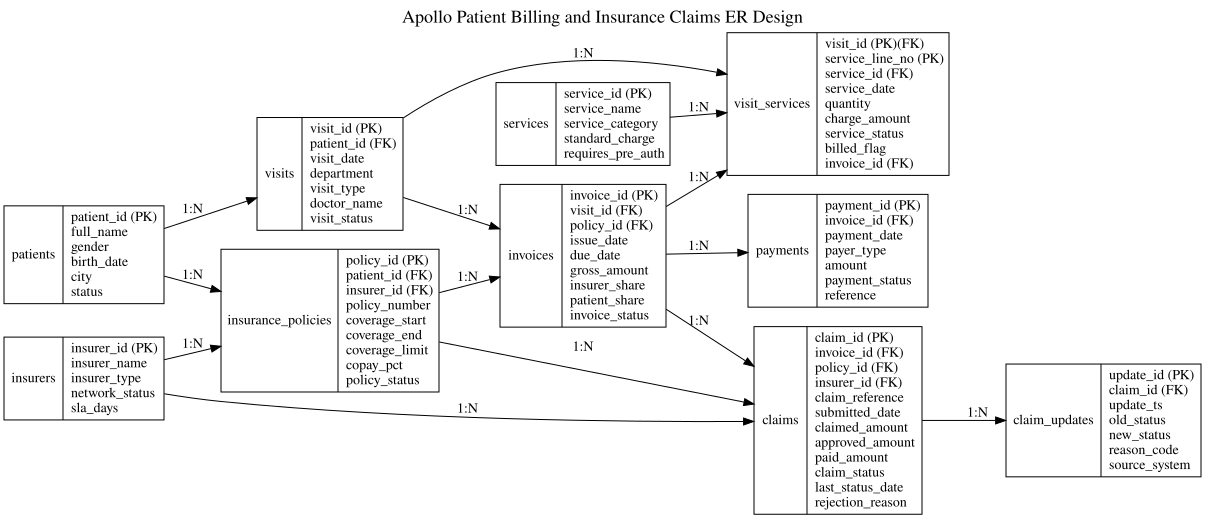

True

In [234]:
developer_tables = {
    "patients": [
        "patient_id (PK)",
        "full_name",
        "gender",
        "birth_date",
        "city",
        "status"
    ],
    "insurers": [
        "insurer_id (PK)",
        "insurer_name",
        "insurer_type",
        "network_status",
        "sla_days"
    ],
    "insurance_policies": [
        "policy_id (PK)",
        "patient_id (FK)",
        "insurer_id (FK)",
        "policy_number",
        "coverage_start",
        "coverage_end",
        "coverage_limit",
        "copay_pct",
        "policy_status"
    ],
    "visits": [
        "visit_id (PK)",
        "patient_id (FK)",
        "visit_date",
        "department",
        "visit_type",
        "doctor_name",
        "visit_status"
    ],
    "services": [
        "service_id (PK)",
        "service_name",
        "service_category",
        "standard_charge",
        "requires_pre_auth"
    ],
    "invoices": [
        "invoice_id (PK)",
        "visit_id (FK)",
        "policy_id (FK)",
        "issue_date",
        "due_date",
        "gross_amount",
        "insurer_share",
        "patient_share",
        "invoice_status"
    ],
    "visit_services": [
        "visit_id (PK)(FK)",
        "service_line_no (PK)",
        "service_id (FK)",
        "service_date",
        "quantity",
        "charge_amount",
        "service_status",
        "billed_flag",
        "invoice_id (FK)"
    ],
    "payments": [
        "payment_id (PK)",
        "invoice_id (FK)",
        "payment_date",
        "payer_type",
        "amount",
        "payment_status",
        "reference"
    ],
    "claims": [
        "claim_id (PK)",
        "invoice_id (FK)",
        "policy_id (FK)",
        "insurer_id (FK)",
        "claim_reference",
        "submitted_date",
        "claimed_amount",
        "approved_amount",
        "paid_amount",
        "claim_status",
        "last_status_date",
        "rejection_reason"
    ],
    "claim_updates": [
        "update_id (PK)",
        "claim_id (FK)",
        "update_ts",
        "old_status",
        "new_status",
        "reason_code",
        "source_system"
    ]
}

developer_relationships = [
    ("patients", "patient_id", "insurance_policies", "patient_id", "1:N"),
    ("insurers", "insurer_id", "insurance_policies", "insurer_id", "1:N"),
    ("patients", "patient_id", "visits", "patient_id", "1:N"),
    ("visits", "visit_id", "invoices", "visit_id", "1:N"),
    ("insurance_policies", "policy_id", "invoices", "policy_id", "1:N"),
    ("visits", "visit_id", "visit_services", "visit_id", "1:N"),
    ("services", "service_id", "visit_services", "service_id", "1:N"),
    ("invoices", "invoice_id", "visit_services", "invoice_id", "1:N"),
    ("invoices", "invoice_id", "payments", "invoice_id", "1:N"),
    ("invoices", "invoice_id", "claims", "invoice_id", "1:N"),
    ("insurance_policies", "policy_id", "claims", "policy_id", "1:N"),
    ("insurers", "insurer_id", "claims", "insurer_id", "1:N"),
    ("claims", "claim_id", "claim_updates", "claim_id", "1:N")
]

validate_er(developer_tables, developer_relationships)

### Expected Output — ER-1

- 10 connected core tables: `patients`, `insurers`, `insurance_policies`, `visits`, `services`, `invoices`, `visit_services`, `payments`, `claims`, `claim_updates`.
- Primary keys and foreign-key markers on all required fields.
- Composite primary key: (`visit_id`, `service_line_no`) in `visit_services`.
- 13 required relationships.
- Validator status: **Passed**.
- A visible ER diagram with all connected tables.

# 3. API Operations

In [235]:
display(api_documentation)

,Method,Endpoint,Purpose,Expected status
0,GET,/patients,Read patient master records,200
1,GET,/insurers,Read insurer master records,200
2,GET,/insurance_policies,Read coverage records,200
3,GET,/visits,Read patient visits,200
4,GET,/services,Read service catalogue,200
5,GET,/invoices,Read billing invoices,200
6,GET,/visit_services,Read delivered service lines,200
7,GET,/payments,Read patient and insurer payments,200
8,GET,/claims,Read claims; supports filters and pagination,200
9,GET,/claim_updates,Read claim-status updates,200


## API-Q1 — Fetch Rejected Claims with Filters

**Business requirement:** The Insurance Claims Operations Lead needs a small review sample of rejected claims before the daily follow-up queue is prepared.

**Endpoint:** `GET /claims`  
**Required filters:** `claim_status=REJECTED`, `limit=5`, `page=1`.

**How to approach:** Use `requests.get`, pass filters through `params`, and use a timeout.

In [236]:
# ✍️ SQL DEVELOPER WORKSPACE — API-Q1
# TODO: Write the filtered requests.get call described above.
params = {
    "claim_status" : "REJECTED",
    "limit" : 5,
    "page" : 1
}
api_q1_response = requests.get(f"{API_BASE_URL}/claims", params=params, timeout = 5)

def api_q1_rule(response,payload):
    records=payload.get('records',[]); passed=response.status_code==200 and len(records)==5 and all(r.get('claim_status')=='REJECTED' for r in records)
    if records: display(pd.DataFrame(records))
    return passed, {'HTTP status':response.status_code,'Record count':len(records),'All REJECTED':all(r.get('claim_status')=='REJECTED' for r in records)}
validate_api('API-Q1',api_q1_response,api_q1_rule)

,claim_id,invoice_id,policy_id,insurer_id,claim_reference,submitted_date,claimed_amount,approved_amount,paid_amount,claim_status,last_status_date,rejection_reason
0,CLM00009,INV00021,POL0046,INS006,CLMREF-000009,2026-06-06,19380.0,0.0,0.0,REJECTED,2026-06-07,POLICY_LIMIT
1,CLM00010,INV00022,POL0081,INS002,CLMREF-000010,2026-05-23,22560.0,0.0,0.0,REJECTED,2026-06-08,MISSING_PREAUTH
2,CLM00017,INV00030,POL0107,INS005,CLMREF-000017,2026-05-25,17595.0,0.0,0.0,REJECTED,2026-05-31,DOCUMENTATION_INCOMPLETE
3,CLM00018,INV00033,POL0011,INS007,CLMREF-000018,2026-05-08,2380.0,0.0,0.0,REJECTED,2026-05-28,COVERAGE_EXCLUDED
4,CLM00021,INV00036,POL0129,INS002,CLMREF-000021,2026-05-28,1925.0,0.0,0.0,REJECTED,2026-05-31,DOCUMENTATION_INCOMPLETE


,HTTP status,Record count,All REJECTED
0,200,5,True


API-Q1: Passed


### Expected Output — API-Q1

| Check | Expected |
|---|---|
| HTTP status | `200` |
| Record count | `5` |
| `claim_status` | Every returned record is `REJECTED` |

## API-Q2 — Create a Claim-Status Update with POST

**Business requirement:** Claims Operations has received a provided insurer acknowledgement that must be created as a new status-update record.

**How to approach:** POST the provided payload to `/claim_updates` with `json=...` and a timeout.

In [237]:
# ✍️ SQL DEVELOPER WORKSPACE — API-Q2
api_q2_payload = {'update_id':'CU-PRACTICE-POST','claim_id':'CLM00001','update_ts':'2026-07-05 12:10:00','old_status':'IN_REVIEW','new_status':'APPROVED','reason_code':'DOCUMENTS_ACCEPTED','source_system':'CLAIMS_DESK'}
reset_remove_update(api_q2_payload['update_id'])
# TODO: POST api_q2_payload to the provided internal API.
api_q2_response = requests.post(f"{API_BASE_URL}/claim_updates", json = api_q2_payload, timeout= 5)

def api_q2_rule(response,payload):
    passed=response.status_code==201 and payload.get('update_id')==api_q2_payload['update_id'] and all(payload.get(k)==v for k,v in api_q2_payload.items())
    if payload: display(pd.DataFrame([payload]))
    return passed, {'HTTP status':response.status_code,'Created ID':payload.get('update_id'),'Payload fields match':all(payload.get(k)==v for k,v in api_q2_payload.items()) if payload else False}
validate_api('API-Q2',api_q2_response,api_q2_rule)

,update_id,claim_id,update_ts,old_status,new_status,reason_code,source_system
0,CU-PRACTICE-POST,CLM00001,2026-07-05 12:10:00,IN_REVIEW,APPROVED,DOCUMENTS_ACCEPTED,CLAIMS_DESK


,HTTP status,Created ID,Payload fields match
0,201,CU-PRACTICE-POST,True


API-Q2: Passed


### Expected Output — API-Q2

| Check | Expected |
|---|---|
| HTTP status | `201` |
| Created ID | `CU-PRACTICE-POST` |
| Payload | All provided fields returned unchanged |

## API-Q3 — Replace a Complete Claim-Status Update with PUT

**Business requirement:** An integration record was created with obsolete values and must be fully replaced after the source feed was corrected.

**How to approach:** The setup resets the practice record first. Use `requests.put` with the complete replacement payload.

In [238]:
# ✍️ SQL DEVELOPER WORKSPACE — API-Q3
api_q3_baseline = {'update_id':'CU-PRACTICE-PUT','claim_id':'CLM00002','update_ts':'2026-07-05 12:20:00','old_status':'SUBMITTED','new_status':'IN_REVIEW','reason_code':'OLD_REASON','source_system':'OLD_FEED'}
api_q3_replacement = {'update_id':'CU-PRACTICE-PUT','claim_id':'CLM00002','update_ts':'2026-07-05 12:25:00','old_status':'IN_REVIEW','new_status':'APPROVED','reason_code':'MEDICAL_REVIEW_COMPLETE','source_system':'INSURER_FEED'}
reset_claim_update(api_q3_baseline)
# TODO: PUT the complete api_q3_replacement payload to /claim_updates/CU-PRACTICE-PUT.
api_q3_response = requests.put(
    f"{API_BASE_URL}/claim_updates/CU-PRACTICE-PUT",
    json = api_q3_replacement,
    timeout = 5
)

def api_q3_rule(response,payload):
    exact=set(payload)==set(api_q3_replacement) and all(payload.get(k)==v for k,v in api_q3_replacement.items())
    if payload: display(pd.DataFrame([payload]))
    return response.status_code==200 and exact, {'HTTP status':response.status_code,'Complete replacement exact':exact,'Unexpected retained fields':sorted(set(payload)-set(api_q3_replacement))}
validate_api('API-Q3',api_q3_response,api_q3_rule)

,update_id,claim_id,update_ts,old_status,new_status,reason_code,source_system
0,CU-PRACTICE-PUT,CLM00002,2026-07-05 12:25:00,IN_REVIEW,APPROVED,MEDICAL_REVIEW_COMPLETE,INSURER_FEED


,HTTP status,Complete replacement exact,Unexpected retained fields
0,200,True,[]


API-Q3: Passed


### Expected Output — API-Q3

| Check | Expected |
|---|---|
| HTTP status | `200` |
| Replacement | Every field equals the provided replacement payload |
| Retained obsolete fields | None |

## API-Q4 — Update Selected Claim Fields with PATCH

**Business requirement:** An insurer only changed the claim status and reason code. No other integration fields should change.

**How to approach:** The baseline record is reset first. Capture it, PATCH only the two supplied fields, and confirm all untargeted values stay unchanged.

In [239]:
# ✍️ SQL DEVELOPER WORKSPACE — API-Q4
api_q4_baseline = {'update_id':'CU-PRACTICE-PATCH','claim_id':'CLM00003','update_ts':'2026-07-05 12:30:00','old_status':'SUBMITTED','new_status':'IN_REVIEW','reason_code':'PENDING_DOCUMENTS','source_system':'INSURER_FEED'}
api_q4_patch = {'new_status':'REJECTED','reason_code':'DOCUMENTATION_INCOMPLETE'}
reset_claim_update(api_q4_baseline)
api_q4_before = requests.get(f"{API_BASE_URL}/claim_updates/{api_q4_baseline['update_id']}",timeout=5).json()
# TODO: PATCH only api_q4_patch to the reset record.
api_q4_response = requests.patch(
    f"{API_BASE_URL}/claim_updates/{api_q4_baseline['update_id']}",
    json=api_q4_patch,
    timeout=5
)

def api_q4_rule(response,payload):
    targeted=all(payload.get(k)==v for k,v in api_q4_patch.items()) if payload else False
    untouched=all(payload.get(k)==api_q4_before.get(k) for k in api_q4_before if k not in api_q4_patch) if payload else False
    if payload: display(pd.DataFrame([payload]))
    return response.status_code==200 and targeted and untouched, {'HTTP status':response.status_code,'Targeted fields changed':targeted,'Untargeted fields unchanged':untouched}
validate_api('API-Q4',api_q4_response,api_q4_rule)

,update_id,claim_id,update_ts,old_status,new_status,reason_code,source_system
0,CU-PRACTICE-PATCH,CLM00003,2026-07-05 12:30:00,SUBMITTED,REJECTED,DOCUMENTATION_INCOMPLETE,INSURER_FEED


,HTTP status,Targeted fields changed,Untargeted fields unchanged
0,200,True,True


API-Q4: Passed


### Expected Output — API-Q4

| Check | Expected |
|---|---|
| HTTP status | `200` |
| Changed fields | `new_status`, `reason_code` only |
| Untargeted fields | Unchanged |

## API-Q5 — GET → DELETE → GET Verification

**Business requirement:** A duplicate practice update must be safely removed and the deletion must be verified.

**How to approach:** Reset the record, GET it, DELETE it, then GET it again using three requests.

In [240]:
# ✍️ SQL DEVELOPER WORKSPACE — API-Q5
api_q5_record = {'update_id':'CU-PRACTICE-DELETE','claim_id':'CLM00004','update_ts':'2026-07-05 12:40:00','old_status':'SUBMITTED','new_status':'IN_REVIEW','reason_code':'DUPLICATE_FEED','source_system':'CLAIMS_GATEWAY'}
reset_claim_update(api_q5_record)
# TODO: Perform GET, DELETE, then GET for CU-PRACTICE-DELETE.
api_q5_before = requests.get(f"{API_BASE_URL}/claim_updates/CU-PRACTICE-DELETE", timeout=5)
api_q5_delete = requests.delete(f"{API_BASE_URL}/claim_updates/CU-PRACTICE-DELETE", timeout=5)
api_q5_after = requests.get(f"{API_BASE_URL}/claim_updates/CU-PRACTICE-DELETE", timeout=5)
if all(x is not None for x in (api_q5_before,api_q5_delete,api_q5_after)):
    statuses=[api_q5_before.status_code,api_q5_delete.status_code,api_q5_after.status_code]
    display(pd.DataFrame({'Step':['GET before','DELETE','GET after'],'HTTP status':statuses}))
    mark_activity('API-Q5',statuses==[200,200,404])
else:
    mark_activity('API-Q5',False,'Write all three requests, then rerun this cell.')

,Step,HTTP status
0,GET before,200
1,DELETE,200
2,GET after,404


API-Q5: Passed


### Expected Output — API-Q5

| Request | Expected status |
|---|---:|
| GET before delete | `200` |
| DELETE | `200` |
| GET after delete | `404` |

# 4. SQL Developer Questions

In [241]:
schema_catalog = pd.DataFrame(conn.execute("SELECT name,type FROM sqlite_master WHERE type IN ('table','index') AND name NOT LIKE 'sqlite_%' ORDER BY type,name").fetchall(),columns=['Object','Type'])
display(schema_catalog)
print('Use the schema and stakeholder requirements below. Complete every SQL requirement in SQL, not Pandas.')

,Object,Type
0,idx_claim_updates_claim_ts,index
1,idx_claims_insurer_status,index
2,idx_claims_invoice,index
3,idx_exceptions_status_type,index
4,idx_invoices_status_due,index
5,idx_payments_invoice_status,index
6,idx_visit_services_invoice,index
7,idx_visits_patient_date,index
8,api_ingestion_runs,table
9,billing_adjustment_ledger,table


Use the schema and stakeholder requirements below. Complete every SQL requirement in SQL, not Pandas.


## 4A. SQL Foundations and Multiple Tables

### Q1 — Largest Outstanding Patient Invoices

**Business requirement:** Revenue Cycle Operations needs the eight largest outstanding invoices still requiring follow-up.

**Tables to use:** `invoices`, `visits`, `patients`, `payments`

**How to approach:** Join invoices to patients through visits, aggregate posted payments, calculate outstanding balance, filter positive balances, then sort descending and limit to eight.

In [242]:
# ✍️ SQL DEVELOPER WORKSPACE — Q1
# TODO: Write the SQL for Q1 here. Keep this TODO guidance visible.payment_id	invoice_id	payment_date	payer_type	amount	payment_status	reference
q1_query = '''
SELECT
        i.invoice_id,
        p.patient_id,
        p.full_name,
        i.gross_amount,
        (i.gross_amount - COALESCE(SUM(pa.amount), 0.0)) AS outstanding_balance
    FROM invoices AS i
    JOIN visits AS v ON i.visit_id = v.visit_id
    JOIN patients AS p ON v.patient_id = p.patient_id
    LEFT JOIN payments AS pa ON i.invoice_id = pa.invoice_id AND pa.payment_status = 'POSTED'
    GROUP BY i.invoice_id, p.patient_id, p.full_name, i.gross_amount
    HAVING outstanding_balance > 0
    ORDER BY outstanding_balance DESC
    LIMIT 8;

'''
validate_sql('Q1', q1_query)

,invoice_id,patient_id,full_name,gross_amount,outstanding_balance
0,INV00340,PAT0069,Rahul Gupta,44900.0,44900.0
1,INV00177,PAT0040,Nisha Iyer,44300.0,44300.0
2,INV00133,PAT0050,Karan Kapoor,48600.0,43740.0
3,INV00431,PAT0069,Rahul Gupta,43200.0,43200.0
4,INV00393,PAT0102,Tara Nair,42100.0,42100.0
5,INV00442,PAT0020,Pooja Das,49300.0,41905.0
6,INV00379,PAT0061,Ananya Kumar,41850.0,41850.0
7,INV00321,PAT0034,Nisha Kapoor,50800.0,40640.0


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q1: Passed


,invoice_id,patient_id,full_name,gross_amount,outstanding_balance
0,INV00340,PAT0069,Rahul Gupta,44900.0,44900.0
1,INV00177,PAT0040,Nisha Iyer,44300.0,44300.0
2,INV00133,PAT0050,Karan Kapoor,48600.0,43740.0
3,INV00431,PAT0069,Rahul Gupta,43200.0,43200.0
4,INV00393,PAT0102,Tara Nair,42100.0,42100.0
5,INV00442,PAT0020,Pooja Das,49300.0,41905.0
6,INV00379,PAT0061,Ananya Kumar,41850.0,41850.0
7,INV00321,PAT0034,Nisha Kapoor,50800.0,40640.0


#### Expected Output — Q1

**Required columns:** `invoice_id` | `patient_id` | `full_name` | `gross_amount` | `outstanding_balance`  
**Expected row count:** **8**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `invoice_id` | `INV00340` |
| `patient_id` | `PAT0069` |
| `full_name` | `Rahul Gupta` |
| `gross_amount` | `44900.0` |
| `outstanding_balance` | `44900.0` |

**Hint:** `JOIN`, `WHERE`, `GROUP BY`, `HAVING`, `ORDER BY`, `LIMIT`

### Q2 — Insurer Claim Volume and Rejection Rate

**Business requirement:** The Claims Manager needs insurer-level claim volume, claimed value, and rejection rate for insurers with material activity.

**Tables to use:** `insurers`, `claims`

**How to approach:** Group claims by insurer; calculate count, claimed value, and rejected percentage; use HAVING for minimum volume and value.

In [243]:
# ✍️ SQL DEVELOPER WORKSPACE — Q2
# TODO: Write the SQL for Q2 here. Keep this TODO guidance visible.
q2_query = '''
    SELECT
        i.insurer_id,
        i.insurer_name,
        COUNT(c.claim_id) AS claim_count,
        SUM(c.claimed_amount) AS claimed_value,
        ROUND(SUM(CASE WHEN c.claim_status = 'REJECTED' THEN 1 ELSE 0 END) * 100.0 / COUNT(c.claim_id), 2) AS rejection_rate_pct
    FROM insurers AS i
    JOIN claims AS c ON i.insurer_id = c.insurer_id
    GROUP BY i.insurer_id, i.insurer_name
    HAVING claim_count >= 10
    ORDER BY rejection_rate_pct DESC;
'''
validate_sql('Q2', q2_query)

,insurer_id,insurer_name,claim_count,claimed_value,rejection_rate_pct
0,INS007,PrimeCare Insurance,23,269745.0,39.13
1,INS003,CareBridge TPA,33,378680.0,30.30
2,INS004,Dhanvantari Assurance,34,388400.0,26.47
3,INS006,National Health Scheme,26,255587.5,23.08
4,INS008,Wellness Shield TPA,44,627832.5,22.73
5,INS002,Bharat Health Cover,58,781410.0,13.79
6,INS005,EverSure Health,32,425555.0,12.50
7,INS001,Aarogya Secure Insurance,40,540007.5,7.50


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q2: Passed


,insurer_id,insurer_name,claim_count,claimed_value,rejection_rate_pct
0,INS007,PrimeCare Insurance,23,269745.0,39.13
1,INS003,CareBridge TPA,33,378680.0,30.30
2,INS004,Dhanvantari Assurance,34,388400.0,26.47
3,INS006,National Health Scheme,26,255587.5,23.08
4,INS008,Wellness Shield TPA,44,627832.5,22.73
5,INS002,Bharat Health Cover,58,781410.0,13.79
6,INS005,EverSure Health,32,425555.0,12.50
7,INS001,Aarogya Secure Insurance,40,540007.5,7.50


#### Expected Output — Q2

**Required columns:** `insurer_id` | `insurer_name` | `claim_count` | `claimed_value` | `rejection_rate_pct`  
**Expected row count:** **8**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `insurer_id` | `INS007` |
| `insurer_name` | `PrimeCare Insurance` |
| `claim_count` | `23` |
| `claimed_value` | `269745.0` |
| `rejection_rate_pct` | `39.13` |

**Hint:** `GROUP BY`, `SUM`, `COUNT`, `CASE`, `HAVING`

### Q3 — Invoice-to-Claim Reconciliation

**Business requirement:** Finance Controls needs insured invoices where approved claim value does not reconcile to the expected insurer share.

**Tables to use:** `invoices`, `insurance_policies`, `insurers`, `claims`

**How to approach:** Join invoice policy and insurer data, LEFT JOIN claims, aggregate approved claim value, and classify each invoice with CASE.

In [244]:
# ✍️ SQL DEVELOPER WORKSPACE — Q3
# TODO: Write the SQL for Q3 here. Keep this SQL guidance visible.
q3_query = '''
    SELECT
        i.invoice_id,
        ins.insurer_name,
        i.insurer_share AS expected_insurer_share,
        COALESCE(SUM(c.approved_amount), 0.0) AS approved_claim_value,
        CASE
            WHEN COALESCE(SUM(c.approved_amount), 0.0) = i.insurer_share THEN 'RECONCILED'
            ELSE 'MISMATCHED'
        END AS reconciliation_status
    FROM invoices AS i
    JOIN insurance_policies AS p ON i.policy_id = p.policy_id
    JOIN insurers AS ins ON p.insurer_id = ins.insurer_id
    LEFT JOIN claims AS c ON i.invoice_id = c.invoice_id
    WHERE i.policy_id IS NOT NULL
    GROUP BY i.invoice_id, ins.insurer_name, i.insurer_share
    HAVING reconciliation_status = 'MISMATCHED'
    ORDER BY i.invoice_id
    limit 20;
'''
validate_sql('Q3', q3_query)

,invoice_id,insurer_name,expected_insurer_share,approved_claim_value,reconciliation_status
0,INV00002,Wellness Shield TPA,28092.5,0.00,MISMATCHED
1,INV00003,EverSure Health,34515.0,24160.50,MISMATCHED
2,INV00005,Bharat Health Cover,6750.0,0.00,MISMATCHED
3,INV00010,CareBridge TPA,3112.5,1867.50,MISMATCHED
4,INV00013,Bharat Health Cover,720.0,0.00,MISMATCHED
5,INV00014,Wellness Shield TPA,6080.0,0.00,MISMATCHED
6,INV00019,Dhanvantari Assurance,11280.0,6768.00,MISMATCHED
7,INV00021,National Health Scheme,19380.0,0.00,MISMATCHED
8,INV00022,Bharat Health Cover,22560.0,0.00,MISMATCHED
9,INV00023,National Health Scheme,11857.5,8300.25,MISMATCHED


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q3: Passed


,invoice_id,insurer_name,expected_insurer_share,approved_claim_value,reconciliation_status
0,INV00002,Wellness Shield TPA,28092.5,0.00,MISMATCHED
1,INV00003,EverSure Health,34515.0,24160.50,MISMATCHED
2,INV00005,Bharat Health Cover,6750.0,0.00,MISMATCHED
3,INV00010,CareBridge TPA,3112.5,1867.50,MISMATCHED
4,INV00013,Bharat Health Cover,720.0,0.00,MISMATCHED
5,INV00014,Wellness Shield TPA,6080.0,0.00,MISMATCHED
6,INV00019,Dhanvantari Assurance,11280.0,6768.00,MISMATCHED
7,INV00021,National Health Scheme,19380.0,0.00,MISMATCHED
8,INV00022,Bharat Health Cover,22560.0,0.00,MISMATCHED
9,INV00023,National Health Scheme,11857.5,8300.25,MISMATCHED


#### Expected Output — Q3

**Required columns:** `invoice_id` | `insurer_name` | `expected_insurer_share` | `approved_claim_value` | `reconciliation_status`  
**Expected row count:** **20**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `invoice_id` | `INV00002` |
| `insurer_name` | `Wellness Shield TPA` |
| `expected_insurer_share` | `28092.5` |
| `approved_claim_value` | `0.0` |
| `reconciliation_status` | `MISMATCHED` |

**Hint:** `LEFT JOIN`, `COALESCE`, `CASE`, aggregation

### Q4 — Delivered Services Not Billed

**Business requirement:** Billing Operations needs delivered service lines that have no matching invoice.

**Tables to use:** `visit_services`, `visits`, `patients`, `services`, `invoices`

**How to approach:** LEFT JOIN the invoice reference and keep delivered lines where the invoice side is NULL. Sort high-value services first.

In [245]:
# ✍️ SQL DEVELOPER WORKSPACE — Q4
# TODO: Write the SQL for Q4 here. Keep this TODO guidance visible.
q4_query = '''select v.visit_id, v.service_line_no, p.patient_id,p.full_name, s.service_name,v.charge_amount
from visit_services as v
join visits as vi on v.visit_id = vi.visit_id
join patients as p on vi.patient_id = p.patient_id
join services as s on v.service_id = s.service_id
left join invoices as i on v.invoice_id = i.invoice_id
where v.service_status = 'DELIVERED' and i.invoice_id is null
order by v.charge_amount desc
limit 15;

'''
validate_sql('Q4', q4_query)

,visit_id,service_line_no,patient_id,full_name,service_name,charge_amount
0,VIS00010,2,PAT0017,Diya Mehta,Chemotherapy Session,28500.0
1,VIS00095,3,PAT0041,Nisha Kumar,Chemotherapy Session,28500.0
2,VIS00181,2,PAT0016,Saanvi Kapoor,Chemotherapy Session,28500.0
3,VIS00559,3,PAT0050,Karan Kapoor,Chemotherapy Session,28500.0
4,VIS00268,2,PAT0049,Nisha Joshi,Day-care Procedure,24000.0
5,VIS00348,3,PAT0011,Meera Singh,Day-care Procedure,24000.0
6,VIS00529,2,PAT0100,Sneha Verma,Day-care Procedure,24000.0
7,VIS00082,1,PAT0015,Pooja Das,Minor Surgical Procedure,18000.0
8,VIS00157,2,PAT0037,Ishaan Sharma,Minor Surgical Procedure,18000.0
9,VIS00290,3,PAT0068,Sneha Kapoor,Minor Surgical Procedure,18000.0


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q4: Passed


,visit_id,service_line_no,patient_id,full_name,service_name,charge_amount
0,VIS00010,2,PAT0017,Diya Mehta,Chemotherapy Session,28500.0
1,VIS00095,3,PAT0041,Nisha Kumar,Chemotherapy Session,28500.0
2,VIS00181,2,PAT0016,Saanvi Kapoor,Chemotherapy Session,28500.0
3,VIS00559,3,PAT0050,Karan Kapoor,Chemotherapy Session,28500.0
4,VIS00268,2,PAT0049,Nisha Joshi,Day-care Procedure,24000.0
5,VIS00348,3,PAT0011,Meera Singh,Day-care Procedure,24000.0
6,VIS00529,2,PAT0100,Sneha Verma,Day-care Procedure,24000.0
7,VIS00082,1,PAT0015,Pooja Das,Minor Surgical Procedure,18000.0
8,VIS00157,2,PAT0037,Ishaan Sharma,Minor Surgical Procedure,18000.0
9,VIS00290,3,PAT0068,Sneha Kapoor,Minor Surgical Procedure,18000.0


#### Expected Output — Q4

**Required columns:** `visit_id` | `service_line_no` | `patient_id` | `full_name` | `service_name` | `charge_amount`  
**Expected row count:** **15**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `visit_id` | `VIS00010` |
| `service_line_no` | `2` |
| `patient_id` | `PAT0017` |
| `full_name` | `Diya Mehta` |
| `service_name` | `Chemotherapy Session` |
| `charge_amount` | `28500.0` |

**Hint:** `LEFT JOIN`, `IS NULL`, anti-join pattern

## 4B. SQL Functions, Set Operations, Subqueries, and CTEs

### Q5 — Rejected-Claim Patients with Outstanding Invoices

**Business requirement:** The claims follow-up team needs patients who appear in both the rejected-claim population and the outstanding-invoice population.

**Tables to use:** `patients`, `visits`, `invoices`, `claims`, `payments`

**How to approach:** Build the two patient sets and combine them with INTERSECT; return patient identity once.

In [246]:
# ✍️ SQL DEVELOPER WORKSPACE — Q5
# TODO: Write the SQL for Q5 here. Keep this TODO guidance visible.
q5_query = '''
    SELECT p.patient_id, p.full_name
    FROM patients AS p
    JOIN visits AS v ON p.patient_id = v.patient_id
    JOIN invoices AS i ON v.visit_id = i.visit_id
    JOIN claims AS c ON i.invoice_id = c.invoice_id
    WHERE c.claim_status = 'REJECTED'

    INTERSECT

    SELECT p.patient_id, p.full_name
    FROM patients AS p
    JOIN visits AS v ON p.patient_id = v.patient_id
    JOIN invoices AS i ON v.visit_id = i.visit_id
    LEFT JOIN payments AS pa ON i.invoice_id = pa.invoice_id AND pa.payment_status = 'POSTED'
    GROUP BY p.patient_id, p.full_name, i.invoice_id, i.gross_amount
    HAVING (i.gross_amount - COALESCE(SUM(pa.amount), 0.0)) > 0

    ORDER BY 1
    limit 36;
'''
validate_sql('Q5', q5_query)

,patient_id,full_name
0,PAT0002,Meera Das
1,PAT0006,Isha Patel
2,PAT0010,Kavya Patel
3,PAT0011,Meera Singh
4,PAT0020,Pooja Das
5,PAT0024,Tara Rao
6,PAT0025,Arjun Gupta
7,PAT0032,Sai Nair
8,PAT0033,Rohan Mehta
9,PAT0039,Arjun Mehta


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q5: Passed


,patient_id,full_name
0,PAT0002,Meera Das
1,PAT0006,Isha Patel
2,PAT0010,Kavya Patel
3,PAT0011,Meera Singh
4,PAT0020,Pooja Das
5,PAT0024,Tara Rao
6,PAT0025,Arjun Gupta
7,PAT0032,Sai Nair
8,PAT0033,Rohan Mehta
9,PAT0039,Arjun Mehta


#### Expected Output — Q5

**Required columns:** `patient_id` | `full_name`  
**Expected row count:** **36**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `patient_id` | `PAT0002` |
| `full_name` | `Meera Das` |

**Hint:** `INTERSECT`, subqueries, aggregation

### Q6 — Insurer Risk Summary with Business-Readable Fields

**Business requirement:** The Revenue Cycle Manager needs normalized insurer labels, recency, rejection rate, and a risk band.

**Tables to use:** `insurers`, `claims`

**How to approach:** Build claim statistics, apply string/date/NULL functions, cast the percentage, and classify risk with CASE.

In [247]:
# ✍️ SQL DEVELOPER WORKSPACE — Q6
# TODO: Write the SQL for Q6 here. Keep this TODO guidance visible.
q6_query = '''
    SELECT
        ins.insurer_id,
        UPPER(ins.insurer_name) AS insurer_name_upper,
        SUBSTR(ins.insurer_name, 1, 12) AS insurer_short_name,
        COUNT(c.claim_id) AS claim_count,
        ROUND(SUM(CASE WHEN c.claim_status = 'REJECTED' THEN 1 ELSE 0 END) * 100.0 / COUNT(c.claim_id), 2) AS rejection_rate_pct,
        CAST(JULIANDAY('2026-07-05') - JULIANDAY(MAX(c.last_status_date)) AS INTEGER) AS days_since_latest_update,
        CASE
            WHEN (SUM(CASE WHEN c.claim_status = 'REJECTED' THEN 1 ELSE 0 END) * 100.0 / COUNT(c.claim_id)) > 30 THEN 'HIGH'
            WHEN (SUM(CASE WHEN c.claim_status = 'REJECTED' THEN 1 ELSE 0 END) * 100.0 / COUNT(c.claim_id)) >= 20 THEN 'MEDIUM'
            ELSE 'LOW'
        END AS risk_band
    FROM insurers AS ins
    JOIN claims AS c ON ins.insurer_id = c.insurer_id
    GROUP BY ins.insurer_id, ins.insurer_name
    ORDER BY rejection_rate_pct DESC;
'''
validate_sql('Q6', q6_query)

,insurer_id,insurer_name_upper,insurer_short_name,claim_count,rejection_rate_pct,days_since_latest_update,risk_band
0,INS007,PRIMECARE INSURANCE,PrimeCare In,23,39.13,0,HIGH
1,INS003,CAREBRIDGE TPA,CareBridge T,33,30.30,0,HIGH
2,INS004,DHANVANTARI ASSURANCE,Dhanvantari,34,26.47,0,MEDIUM
3,INS006,NATIONAL HEALTH SCHEME,National Hea,26,23.08,0,MEDIUM
4,INS008,WELLNESS SHIELD TPA,Wellness Shi,44,22.73,0,MEDIUM
5,INS002,BHARAT HEALTH COVER,Bharat Healt,58,13.79,0,LOW
6,INS005,EVERSURE HEALTH,EverSure Hea,32,12.50,0,LOW
7,INS001,AAROGYA SECURE INSURANCE,Aarogya Secu,40,7.50,0,LOW


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q6: Passed


,insurer_id,insurer_name_upper,insurer_short_name,claim_count,rejection_rate_pct,days_since_latest_update,risk_band
0,INS007,PRIMECARE INSURANCE,PrimeCare In,23,39.13,0,HIGH
1,INS003,CAREBRIDGE TPA,CareBridge T,33,30.30,0,HIGH
2,INS004,DHANVANTARI ASSURANCE,Dhanvantari,34,26.47,0,MEDIUM
3,INS006,NATIONAL HEALTH SCHEME,National Hea,26,23.08,0,MEDIUM
4,INS008,WELLNESS SHIELD TPA,Wellness Shi,44,22.73,0,MEDIUM
5,INS002,BHARAT HEALTH COVER,Bharat Healt,58,13.79,0,LOW
6,INS005,EVERSURE HEALTH,EverSure Hea,32,12.50,0,LOW
7,INS001,AAROGYA SECURE INSURANCE,Aarogya Secu,40,7.50,0,LOW


#### Expected Output — Q6

**Required columns:** `insurer_id` | `insurer_name_upper` | `insurer_short_name` | `claim_count` | `rejection_rate_pct` | `days_since_latest_update` | `risk_band`  
**Expected row count:** **8**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `insurer_id` | `INS007` |
| `insurer_name_upper` | `PRIMECARE INSURANCE` |
| `insurer_short_name` | `PrimeCare In` |
| `claim_count` | `23` |
| `rejection_rate_pct` | `39.13` |
| `days_since_latest_update` | `0` |
| `risk_band` | `HIGH` |

**Hint:** `UPPER`, `SUBSTR`, `COALESCE`, date functions, `CAST`, `CASE`

### Q7 — Insurers Above Average Rejection Rate

**Business requirement:** The Claims Manager needs insurers whose rejection rate is higher than the portfolio average.

**Tables to use:** `insurers`, `claims`

**How to approach:** Calculate insurer rejection rates in a CTE and compare each rate with a scalar subquery returning the average.

In [248]:
# ✍️ SQL DEVELOPER WORKSPACE — Q7
# TODO: Write the SQL for Q7 here. Keep this TODO guidance visible.
q7_query = ''' WITH insurer_stats AS (
    SELECT
        i.insurer_id,
        i.insurer_name,
        COUNT(c.claim_id) AS claim_count,
        ROUND(SUM(CASE WHEN c.claim_status = 'REJECTED' THEN 1 ELSE 0 END) * 100.0 / COUNT(c.claim_id), 2) AS rejection_rate_pct
    FROM insurers AS i
    JOIN claims AS c ON i.insurer_id = c.insurer_id
    GROUP BY i.insurer_id, i.insurer_name
    HAVING claim_count >= 10
)
SELECT
    insurer_id,
    insurer_name,
    claim_count,
    rejection_rate_pct
FROM insurer_stats
WHERE rejection_rate_pct > (SELECT AVG(rejection_rate_pct) FROM insurer_stats)
ORDER BY rejection_rate_pct DESC;
'''
validate_sql('Q7', q7_query)

,insurer_id,insurer_name,claim_count,rejection_rate_pct
0,INS007,PrimeCare Insurance,23,39.13
1,INS003,CareBridge TPA,33,30.30
2,INS004,Dhanvantari Assurance,34,26.47
3,INS006,National Health Scheme,26,23.08
4,INS008,Wellness Shield TPA,44,22.73


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q7: Passed


,insurer_id,insurer_name,claim_count,rejection_rate_pct
0,INS007,PrimeCare Insurance,23,39.13
1,INS003,CareBridge TPA,33,30.30
2,INS004,Dhanvantari Assurance,34,26.47
3,INS006,National Health Scheme,26,23.08
4,INS008,Wellness Shield TPA,44,22.73


#### Expected Output — Q7

**Required columns:** `insurer_id` | `insurer_name` | `claim_count` | `rejection_rate_pct`  
**Expected row count:** **5**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `insurer_id` | `INS007` |
| `insurer_name` | `PrimeCare Insurance` |
| `claim_count` | `23` |
| `rejection_rate_pct` | `39.13` |

**Hint:** standard CTE, scalar subquery

### Q8 — Multi-Stage Billing and Claims Control

**Business requirement:** Finance Controls needs a compact invoice control view comparing billed service value, claim value, posted payments, and outstanding balance.

**Tables to use:** `invoices`, `visit_services`, `payments`, `claims`

**How to approach:** Use separate standard CTEs for billed services, posted payments, and claims, then combine and classify each invoice.

In [249]:
# ✍️ SQL DEVELOPER WORKSPACE — Q8
# TODO: Write the SQL for Q8 here. Keep this TODO guidance visible.
q8_query = '''WITH billed AS (
    SELECT invoice_id, SUM(charge_amount) AS billed_service_value
    FROM visit_services
    WHERE invoice_id IS NOT NULL
    GROUP BY invoice_id
),
payments_agg AS (
    SELECT invoice_id, SUM(amount) AS posted_payment_value
    FROM payments
    WHERE payment_status = 'POSTED'
    GROUP BY invoice_id
),
claims_agg AS (
    SELECT invoice_id, SUM(claimed_amount) AS total_claimed
    FROM claims
    GROUP BY invoice_id
)
SELECT
    i.invoice_id,
    COALESCE(b.billed_service_value, 0.0) AS billed_service_value,
    i.gross_amount AS invoice_gross,
    COALESCE(c.total_claimed, 0.0) AS total_claimed,
    COALESCE(p.posted_payment_value, 0.0) AS posted_payment_value,
    (i.gross_amount - COALESCE(p.posted_payment_value, 0.0)) AS outstanding_balance,
    CASE
        WHEN (i.gross_amount - COALESCE(p.posted_payment_value, 0.0)) <= 0 THEN 'SETTLED'
        WHEN COALESCE(c.total_claimed, 0.0) > 0 THEN 'CLAIM_IN_PROGRESS'
        ELSE 'OUTSTANDING'
    END AS control_status
FROM invoices AS i
LEFT JOIN billed AS b ON i.invoice_id = b.invoice_id
LEFT JOIN payments_agg AS p ON i.invoice_id = p.invoice_id
LEFT JOIN claims_agg AS c ON i.invoice_id = c.invoice_id
ORDER BY outstanding_balance DESC
LIMIT 20;'''
validate_sql('Q8', q8_query)

,invoice_id,billed_service_value,invoice_gross,total_claimed,posted_payment_value,outstanding_balance,control_status
0,INV00340,44900.0,44900.0,0.0,0.0,44900.0,OUTSTANDING
1,INV00177,44300.0,44300.0,0.0,0.0,44300.0,OUTSTANDING
2,INV00133,48600.0,48600.0,43740.0,4860.0,43740.0,CLAIM_IN_PROGRESS
3,INV00431,43200.0,43200.0,0.0,0.0,43200.0,OUTSTANDING
4,INV00393,42100.0,42100.0,33680.0,0.0,42100.0,CLAIM_IN_PROGRESS
5,INV00442,49300.0,49300.0,41905.0,7395.0,41905.0,CLAIM_IN_PROGRESS
6,INV00379,41850.0,41850.0,0.0,0.0,41850.0,OUTSTANDING
7,INV00321,50800.0,50800.0,40640.0,10160.0,40640.0,CLAIM_IN_PROGRESS
8,INV00025,40500.0,40500.0,36450.0,0.0,40500.0,CLAIM_IN_PROGRESS
9,INV00281,54000.0,54000.0,40500.0,13500.0,40500.0,CLAIM_IN_PROGRESS


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q8: Passed


,invoice_id,billed_service_value,invoice_gross,total_claimed,posted_payment_value,outstanding_balance,control_status
0,INV00340,44900.0,44900.0,0.0,0.0,44900.0,OUTSTANDING
1,INV00177,44300.0,44300.0,0.0,0.0,44300.0,OUTSTANDING
2,INV00133,48600.0,48600.0,43740.0,4860.0,43740.0,CLAIM_IN_PROGRESS
3,INV00431,43200.0,43200.0,0.0,0.0,43200.0,OUTSTANDING
4,INV00393,42100.0,42100.0,33680.0,0.0,42100.0,CLAIM_IN_PROGRESS
5,INV00442,49300.0,49300.0,41905.0,7395.0,41905.0,CLAIM_IN_PROGRESS
6,INV00379,41850.0,41850.0,0.0,0.0,41850.0,OUTSTANDING
7,INV00321,50800.0,50800.0,40640.0,10160.0,40640.0,CLAIM_IN_PROGRESS
8,INV00025,40500.0,40500.0,36450.0,0.0,40500.0,CLAIM_IN_PROGRESS
9,INV00281,54000.0,54000.0,40500.0,13500.0,40500.0,CLAIM_IN_PROGRESS


#### Expected Output — Q8

**Required columns:** `invoice_id` | `billed_service_value` | `invoice_gross` | `total_claimed` | `posted_payment_value` | `outstanding_balance` | `control_status`  
**Expected row count:** **20**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `invoice_id` | `INV00340` |
| `billed_service_value` | `44900.0` |
| `invoice_gross` | `44900.0` |
| `total_claimed` | `0.0` |
| `posted_payment_value` | `0.0` |
| `outstanding_balance` | `44900.0` |
| `control_status` | `OUTSTANDING` |

**Hint:** multiple standard CTEs, `COALESCE`, `CASE`

## 4C. Window Functions

### Q9 — Rank Insurers by Rejection Rate

**Business requirement:** The Insurance Operations Head needs insurer rejection ranking within each insurer type.

**Tables to use:** `insurers`, `claims`

**How to approach:** Aggregate rates first, then rank within insurer type by rejection rate.

In [250]:
# ✍️ SQL DEVELOPER WORKSPACE — Q9
# TODO: Write the SQL for Q9 here. Keep this TODO guidance visible.
q9_query = '''WITH insurer_stats AS (
    SELECT
        i.insurer_type,
        i.insurer_id,
        i.insurer_name,
        COUNT(c.claim_id) AS claim_count,
        ROUND(SUM(CASE WHEN c.claim_status = 'REJECTED' THEN 1 ELSE 0 END) * 100.0 / COUNT(c.claim_id), 2) AS rejection_rate_pct
    FROM insurers AS i
    JOIN claims AS c ON i.insurer_id = c.insurer_id
    GROUP BY i.insurer_type, i.insurer_id, i.insurer_name
    HAVING claim_count >= 10
)
SELECT
    insurer_type,
    insurer_id,
    insurer_name,
    claim_count,
    rejection_rate_pct,
    RANK() OVER (PARTITION BY insurer_type ORDER BY rejection_rate_pct DESC) AS rejection_rank
FROM insurer_stats
ORDER BY insurer_type, rejection_rank;'''
validate_sql('Q9', q9_query)

,insurer_type,insurer_id,insurer_name,claim_count,rejection_rate_pct,rejection_rank
0,GOVERNMENT,INS006,National Health Scheme,26,23.08,1
1,PRIVATE,INS007,PrimeCare Insurance,23,39.13,1
2,PRIVATE,INS004,Dhanvantari Assurance,34,26.47,2
3,PRIVATE,INS002,Bharat Health Cover,58,13.79,3
4,PRIVATE,INS005,EverSure Health,32,12.50,4
5,PRIVATE,INS001,Aarogya Secure Insurance,40,7.50,5
6,TPA,INS003,CareBridge TPA,33,30.30,1
7,TPA,INS008,Wellness Shield TPA,44,22.73,2


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q9: Passed


,insurer_type,insurer_id,insurer_name,claim_count,rejection_rate_pct,rejection_rank
0,GOVERNMENT,INS006,National Health Scheme,26,23.08,1
1,PRIVATE,INS007,PrimeCare Insurance,23,39.13,1
2,PRIVATE,INS004,Dhanvantari Assurance,34,26.47,2
3,PRIVATE,INS002,Bharat Health Cover,58,13.79,3
4,PRIVATE,INS005,EverSure Health,32,12.50,4
5,PRIVATE,INS001,Aarogya Secure Insurance,40,7.50,5
6,TPA,INS003,CareBridge TPA,33,30.30,1
7,TPA,INS008,Wellness Shield TPA,44,22.73,2


#### Expected Output — Q9

**Required columns:** `insurer_type` | `insurer_id` | `insurer_name` | `claim_count` | `rejection_rate_pct` | `rejection_rank`  
**Expected row count:** **8**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `insurer_type` | `GOVERNMENT` |
| `insurer_id` | `INS006` |
| `insurer_name` | `National Health Scheme` |
| `claim_count` | `26` |
| `rejection_rate_pct` | `23.08` |
| `rejection_rank` | `1` |

**Hint:** `RANK()`, `PARTITION BY`

### Q10 — Daily Claimed Value Running Total and Moving Average

**Business requirement:** Finance Planning needs daily claimed value, cumulative claimed value, and a seven-day moving average.

**Tables to use:** `claims`

**How to approach:** Aggregate daily claimed value and apply SUM and AVG window frames ordered by submission date.

In [251]:
# ✍️ SQL DEVELOPER WORKSPACE — Q10
# TODO: Write the SQL for Q10 here. Keep this TODO guidance visible.
q10_query = '''WITH daily_claims AS (
    SELECT
        submitted_date,
        SUM(claimed_amount) AS daily_claimed_value
    FROM claims
    GROUP BY submitted_date
)
SELECT
    submitted_date,
    daily_claimed_value,
    SUM(daily_claimed_value) OVER (
        ORDER BY submitted_date
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS running_claimed_value,
    AVG(daily_claimed_value) OVER (
        ORDER BY submitted_date
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ) AS moving_7day_avg
FROM daily_claims
ORDER BY submitted_date;'''
validate_sql('Q10', q10_query)

,submitted_date,daily_claimed_value,running_claimed_value,moving_7day_avg
0,2026-04-03,22950.0,22950.0,22950.000000
1,2026-04-04,3740.0,26690.0,13345.000000
2,2026-04-05,16185.0,42875.0,14291.666667
3,2026-04-06,1010.0,43885.0,10971.250000
4,2026-04-07,63130.0,107015.0,21403.000000
5,2026-04-08,3150.0,110165.0,18360.833333
6,2026-04-09,50757.5,160922.5,22988.928571
7,2026-04-10,74022.5,234945.0,30285.000000
8,2026-04-11,39557.5,274502.5,35401.785714
9,2026-04-12,61790.0,336292.5,41916.785714


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q10: Passed


,submitted_date,daily_claimed_value,running_claimed_value,moving_7day_avg
0,2026-04-03,22950.0,22950.0,22950.000000
1,2026-04-04,3740.0,26690.0,13345.000000
2,2026-04-05,16185.0,42875.0,14291.666667
3,2026-04-06,1010.0,43885.0,10971.250000
4,2026-04-07,63130.0,107015.0,21403.000000
5,2026-04-08,3150.0,110165.0,18360.833333
6,2026-04-09,50757.5,160922.5,22988.928571
7,2026-04-10,74022.5,234945.0,30285.000000
8,2026-04-11,39557.5,274502.5,35401.785714
9,2026-04-12,61790.0,336292.5,41916.785714


#### Expected Output — Q10

**Required columns:** `submitted_date` | `daily_claimed_value` | `running_claimed_value` | `moving_7day_avg`  
**Expected row count:** **89**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `submitted_date` | `2026-04-03` |
| `daily_claimed_value` | `22950.0` |
| `running_claimed_value` | `22950.0` |
| `moving_7day_avg` | `22950.0` |

**Hint:** window `SUM`, window `AVG`, frame clauses

### Q11 — Day-over-Day Rejection Rate Comparison

**Business requirement:** Claims Operations needs daily rejection rate and its percentage change from the previous active claim day.

**Tables to use:** `claims`

**How to approach:** Aggregate daily counts, calculate daily rejection rate, use LAG, and safely handle null or zero prior rates.

In [252]:
# ✍️ SQL DEVELOPER WORKSPACE — Q11
# TODO: Write the SQL for Q11 here. Keep this TODO guidance visible.
q11_query = '''WITH daily_claims AS (
    SELECT
        submitted_date,
        COUNT(claim_id) AS claims_submitted,
        SUM(CASE WHEN claim_status = 'REJECTED' THEN 1 ELSE 0 END) AS rejected_claims,
        ROUND(SUM(CASE WHEN claim_status = 'REJECTED' THEN 1 ELSE 0 END) * 100.0 / COUNT(claim_id), 2) AS rejection_rate_pct
    FROM claims
    GROUP BY submitted_date
),
lagged_claims AS (
    SELECT
        submitted_date,
        claims_submitted,
        rejected_claims,
        rejection_rate_pct,
        LAG(rejection_rate_pct, 1) OVER (ORDER BY submitted_date) AS prior_day_rejection_rate
    FROM daily_claims
)
SELECT
    submitted_date,
    claims_submitted,
    rejected_claims,
    rejection_rate_pct,
    prior_day_rejection_rate,
    CASE
        WHEN prior_day_rejection_rate IS NULL OR prior_day_rejection_rate = 0 THEN NULL
        ELSE ROUND((rejection_rate_pct - prior_day_rejection_rate) * 100.0 / prior_day_rejection_rate, 2)
    END AS rejection_rate_change_pct
FROM lagged_claims
ORDER BY submitted_date;'''
validate_sql('Q11', q11_query)

,submitted_date,claims_submitted,rejected_claims,rejection_rate_pct,prior_day_rejection_rate,rejection_rate_change_pct
0,2026-04-03,1,0,0.00,NaN,NaN
1,2026-04-04,1,0,0.00,0.00,NaN
2,2026-04-05,3,1,33.33,0.00,NaN
3,2026-04-06,2,0,0.00,33.33,-100.00
4,2026-04-07,6,0,0.00,0.00,NaN
5,2026-04-08,1,0,0.00,0.00,NaN
6,2026-04-09,4,1,25.00,0.00,NaN
7,2026-04-10,6,0,0.00,25.00,-100.00
8,2026-04-11,5,1,20.00,0.00,NaN
9,2026-04-12,5,0,0.00,20.00,-100.00


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q11: Passed


,submitted_date,claims_submitted,rejected_claims,rejection_rate_pct,prior_day_rejection_rate,rejection_rate_change_pct
0,2026-04-03,1,0,0.00,NaN,NaN
1,2026-04-04,1,0,0.00,0.00,NaN
2,2026-04-05,3,1,33.33,0.00,NaN
3,2026-04-06,2,0,0.00,33.33,-100.00
4,2026-04-07,6,0,0.00,0.00,NaN
5,2026-04-08,1,0,0.00,0.00,NaN
6,2026-04-09,4,1,25.00,0.00,NaN
7,2026-04-10,6,0,0.00,25.00,-100.00
8,2026-04-11,5,1,20.00,0.00,NaN
9,2026-04-12,5,0,0.00,20.00,-100.00


#### Expected Output — Q11

**Required columns:** `submitted_date` | `claims_submitted` | `rejected_claims` | `rejection_rate_pct` | `prior_day_rejection_rate` | `rejection_rate_change_pct`  
**Expected row count:** **89**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `submitted_date` | `2026-04-03` |
| `claims_submitted` | `1` |
| `rejected_claims` | `0` |
| `rejection_rate_pct` | `0.0` |
| `prior_day_rejection_rate` | `NULL` |
| `rejection_rate_change_pct` | `NULL` |

**Hint:** `LAG`, safe percentage calculation

### Q12 — First and Latest Claim Status per Claim

**Business requirement:** The Claims Manager wants the first and latest status event for a review sample of claims.

**Tables to use:** `claim_updates`

**How to approach:** Assign ascending and descending ROW_NUMBER values per claim, then use conditional aggregation.

In [253]:
# ✍️ SQL DEVELOPER WORKSPACE — Q12
# TODO: Write the SQL for Q12 here. Keep this TODO guidance visible.
q12_query = '''WITH ranked_updates AS (
    SELECT
        claim_id,
        new_status AS status_val,
        update_ts,
        ROW_NUMBER() OVER (PARTITION BY claim_id ORDER BY update_ts ASC, update_id ASC) AS rn_asc,
        ROW_NUMBER() OVER (PARTITION BY claim_id ORDER BY update_ts DESC, update_id DESC) AS rn_desc
    FROM claim_updates
)
SELECT
    claim_id,
    MAX(CASE WHEN rn_asc = 1 THEN status_val END) AS first_status,
    MAX(CASE WHEN rn_asc = 1 THEN update_ts END) AS first_status_ts,
    MAX(CASE WHEN rn_desc = 1 THEN status_val END) AS latest_status,
    MAX(CASE WHEN rn_desc = 1 THEN update_ts END) AS latest_status_ts
FROM ranked_updates
GROUP BY claim_id
ORDER BY claim_id
limit 20;'''
validate_sql('Q12', q12_query)

,claim_id,first_status,first_status_ts,latest_status,latest_status_ts
0,CLM00001,SUBMITTED,2026-06-18 09:00:00,IN_REVIEW,2026-06-27 16:00:00
1,CLM00002,SUBMITTED,2026-04-10 09:00:00,PARTIALLY_APPROVED,2026-04-12 16:00:00
2,CLM00003,SUBMITTED,2026-06-11 09:00:00,APPROVED,2026-06-22 16:00:00
3,CLM00004,SUBMITTED,2026-06-27 09:00:00,IN_REVIEW,2026-07-05 16:00:00
4,CLM00005,SUBMITTED,2026-05-12 09:00:00,PARTIALLY_APPROVED,2026-05-23 16:00:00
5,CLM00006,SUBMITTED,2026-06-02 09:00:00,IN_REVIEW,2026-06-04 16:00:00
6,CLM00007,SUBMITTED,2026-05-25 09:00:00,PAID,2026-06-09 16:00:00
7,CLM00008,SUBMITTED,2026-06-16 09:00:00,PARTIALLY_APPROVED,2026-06-21 16:00:00
8,CLM00009,SUBMITTED,2026-06-06 09:00:00,REJECTED,2026-06-07 16:00:00
9,CLM00010,SUBMITTED,2026-05-23 09:00:00,REJECTED,2026-06-08 16:00:00


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q12: Passed


,claim_id,first_status,first_status_ts,latest_status,latest_status_ts
0,CLM00001,SUBMITTED,2026-06-18 09:00:00,IN_REVIEW,2026-06-27 16:00:00
1,CLM00002,SUBMITTED,2026-04-10 09:00:00,PARTIALLY_APPROVED,2026-04-12 16:00:00
2,CLM00003,SUBMITTED,2026-06-11 09:00:00,APPROVED,2026-06-22 16:00:00
3,CLM00004,SUBMITTED,2026-06-27 09:00:00,IN_REVIEW,2026-07-05 16:00:00
4,CLM00005,SUBMITTED,2026-05-12 09:00:00,PARTIALLY_APPROVED,2026-05-23 16:00:00
5,CLM00006,SUBMITTED,2026-06-02 09:00:00,IN_REVIEW,2026-06-04 16:00:00
6,CLM00007,SUBMITTED,2026-05-25 09:00:00,PAID,2026-06-09 16:00:00
7,CLM00008,SUBMITTED,2026-06-16 09:00:00,PARTIALLY_APPROVED,2026-06-21 16:00:00
8,CLM00009,SUBMITTED,2026-06-06 09:00:00,REJECTED,2026-06-07 16:00:00
9,CLM00010,SUBMITTED,2026-05-23 09:00:00,REJECTED,2026-06-08 16:00:00


#### Expected Output — Q12

**Required columns:** `claim_id` | `first_status` | `first_status_ts` | `latest_status` | `latest_status_ts`  
**Expected row count:** **20**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `claim_id` | `CLM00001` |
| `first_status` | `SUBMITTED` |
| `first_status_ts` | `2026-06-18 09:00:00` |
| `latest_status` | `IN_REVIEW` |
| `latest_status_ts` | `2026-06-27 16:00:00` |

**Hint:** `ROW_NUMBER`, conditional aggregation

### Q13 — Top Exception Types per Patient City with Ties

**Business requirement:** Revenue Cycle leadership wants the top three exception ranks in each patient city without dropping tied exception counts.

**Tables to use:** `billing_claim_exceptions`, `patients`

**How to approach:** Aggregate open exception counts by city and type, apply DENSE_RANK by count, and filter ranks one to three.

In [254]:
# ✍️ SQL DEVELOPER WORKSPACE — Q13
# TODO: Write the SQL for Q13 here. Keep this TODO guidance visible.
q13_query = '''WITH city_exceptions AS (
    SELECT
        p.city,
        e.exception_type,
        COUNT(e.exception_id) AS exception_count,
        SUM(e.exception_amount) AS exception_value
    FROM billing_claim_exceptions AS e
    JOIN visits AS v ON e.visit_id = v.visit_id
    JOIN patients AS p ON v.patient_id = p.patient_id
    WHERE e.status = 'OPEN'
    GROUP BY p.city, e.exception_type
),
ranked_exceptions AS (
    SELECT
        city,
        exception_type,
        exception_count,
        exception_value,
        DENSE_RANK() OVER (PARTITION BY city ORDER BY exception_count DESC) AS city_exception_rank
    FROM city_exceptions
)
SELECT
    city,
    exception_type,
    exception_count,
    exception_value,
    city_exception_rank
FROM ranked_exceptions
WHERE city_exception_rank <= 3
ORDER BY city, city_exception_rank, exception_count DESC;'''
validate_sql('Q13', q13_query)

,city,exception_type,exception_count,exception_value,city_exception_rank
0,Ahmedabad,OVERDUE_OUTSTANDING_INVOICE,35,366283.50,1
1,Ahmedabad,UNBILLED_DELIVERED_SERVICE,15,99250.00,2
2,Ahmedabad,OVERDUE_OPEN_CLAIM,8,75252.50,3
3,Ahmedabad,REJECTED_CLAIM,8,84785.00,3
4,Bengaluru,OVERDUE_OUTSTANDING_INVOICE,48,594869.25,1
5,Bengaluru,UNBILLED_DELIVERED_SERVICE,15,79550.00,2
6,Bengaluru,OVERDUE_OPEN_CLAIM,11,162967.50,3
7,Chennai,OVERDUE_OUTSTANDING_INVOICE,30,329232.50,1
8,Chennai,UNBILLED_DELIVERED_SERVICE,12,55250.00,2
9,Chennai,OVERDUE_OPEN_CLAIM,6,48182.50,3


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


Q13: Passed


,city,exception_type,exception_count,exception_value,city_exception_rank
0,Ahmedabad,OVERDUE_OUTSTANDING_INVOICE,35,366283.50,1
1,Ahmedabad,UNBILLED_DELIVERED_SERVICE,15,99250.00,2
2,Ahmedabad,OVERDUE_OPEN_CLAIM,8,75252.50,3
3,Ahmedabad,REJECTED_CLAIM,8,84785.00,3
4,Bengaluru,OVERDUE_OUTSTANDING_INVOICE,48,594869.25,1
5,Bengaluru,UNBILLED_DELIVERED_SERVICE,15,79550.00,2
6,Bengaluru,OVERDUE_OPEN_CLAIM,11,162967.50,3
7,Chennai,OVERDUE_OUTSTANDING_INVOICE,30,329232.50,1
8,Chennai,UNBILLED_DELIVERED_SERVICE,12,55250.00,2
9,Chennai,OVERDUE_OPEN_CLAIM,6,48182.50,3


#### Expected Output — Q13

**Required columns:** `city` | `exception_type` | `exception_count` | `exception_value` | `city_exception_rank`  
**Expected row count:** **25**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `city` | `Ahmedabad` |
| `exception_type` | `OVERDUE_OUTSTANDING_INVOICE` |
| `exception_count` | `35` |
| `exception_value` | `366283.5` |
| `city_exception_rank` | `1` |

**Hint:** `DENSE_RANK`, `PARTITION BY`, filtering

# 5. Transaction Management

## T1 — Commit an Approved Billing Adjustment

**Business requirement:** Finance has approved a small billing correction for a reviewed invoice. The adjustment must remain in the ledger after the transaction commits.

**How to approach:** Reset the fixed activity ID, then execute `BEGIN → INSERT → COMMIT` using the provided values.

In [255]:
# ✍️ SQL DEVELOPER WORKSPACE — T1
conn.execute("DELETE FROM billing_adjustment_ledger WHERE adjustment_id='ADJ-DEVELOPER-COMMIT'"); conn.commit()
# TODO: Write BEGIN; INSERT the approved adjustment; COMMIT; Keep this TODO guidance visible.
t1_sql = """
BEGIN;

INSERT INTO billing_adjustment_ledger
VALUES (
    'ADJ-DEVELOPER-COMMIT',
    'INV00001',
    (SELECT v.patient_id FROM visits v JOIN invoices i ON v.visit_id = i.visit_id WHERE i.invoice_id = 'INV00001'),
    'BILLING_CORRECTION',
    -250.00,
    1,
    '2026-07-05 14:00:00',
    'Approved duplicate-service correction'
);

COMMIT;
"""
if _sql_body(t1_sql):
    try:
        conn.executescript(t1_sql)
        present=conn.execute("SELECT COUNT(*) FROM billing_adjustment_ledger WHERE adjustment_id='ADJ-DEVELOPER-COMMIT'").fetchone()[0]==1
        display(run_query("SELECT * FROM billing_adjustment_ledger WHERE adjustment_id='ADJ-DEVELOPER-COMMIT'")); mark_activity('T1',present,f'Actual row present: {present}')
    except Exception as exc:
        try: conn.rollback()
        except Exception: pass
        mark_activity('T1',False,f'Transaction could not run: {exc}')
else: mark_activity('T1',False,'Write the transaction script, then rerun this cell.')

,adjustment_id,invoice_id,patient_id,adjustment_type,amount,approved_flag,adjustment_ts,note
0,ADJ-DEVELOPER-COMMIT,INV00001,PAT0096,BILLING_CORRECTION,-250.0,1,2026-07-05 14:00:00,Approved duplicate-service correction


T1: Passed | Actual row present: True


### Expected Output — T1

Use this approved record:

`ADJ-DEVELOPER-COMMIT | INV00001 | linked patient | BILLING_CORRECTION | -250.00 | approved | 2026-07-05 14:00:00 | Approved duplicate-service correction`

Validation must report **Actual row present: True** and **Passed**.

## T2 — Roll Back an Unapproved Temporary Adjustment

**Business requirement:** A temporary write-off proposal is not approved. The database must prove that the attempted ledger row does not persist.

**How to approach:** Reset the fixed activity ID, execute `BEGIN → INSERT → ROLLBACK`, then query the ledger.

In [256]:
# ✍️ SQL DEVELOPER WORKSPACE — T2
conn.execute("DELETE FROM billing_adjustment_ledger WHERE adjustment_id='ADJ-DEVELOPER-ROLLBACK'"); conn.commit()
# TODO: Write BEGIN; INSERT the temporary adjustment; ROLLBACK; Keep this TODO guidance visible.
t2_sql = """
BEGIN;

INSERT INTO billing_adjustment_ledger
VALUES (
    'ADJ-DEVELOPER-ROLLBACK',
    'INV00002',
    (SELECT v.patient_id FROM visits v JOIN invoices i ON v.visit_id = i.visit_id WHERE i.invoice_id = 'INV00002'),
    'TEMPORARY_REVIEW',
    -500.00,
    0,
    '2026-07-05 14:15:00',
    'Unapproved temporary write-off'
);

ROLLBACK;
"""
if _sql_body(t2_sql):
    try:
        conn.executescript(t2_sql)
        present=conn.execute("SELECT COUNT(*) FROM billing_adjustment_ledger WHERE adjustment_id='ADJ-DEVELOPER-ROLLBACK'").fetchone()[0]==1
        display(run_query("SELECT * FROM billing_adjustment_ledger WHERE adjustment_id='ADJ-DEVELOPER-ROLLBACK'")); mark_activity('T2',not present,f'Actual row present: {present}')
    except Exception as exc:
        try: conn.rollback()
        except Exception: pass
        mark_activity('T2',False,f'Transaction could not run: {exc}')
else: mark_activity('T2',False,'Write the transaction script, then rerun this cell.')

,adjustment_id,invoice_id,patient_id,adjustment_type,amount,approved_flag,adjustment_ts,note


T2: Passed | Actual row present: False


### Expected Output — T2

Use this temporary record:

`ADJ-DEVELOPER-ROLLBACK | INV00002 | linked patient | TEMPORARY_REVIEW | -500.00 | not approved | 2026-07-05 14:15:00 | Unapproved temporary write-off`

Validation must report **Actual row present: False** and **Passed**.

# 6. Workflow Automation

## AUTO-FLOW — Design the Claims Follow-Up Automation

**Business requirement:** Claims Operations wants a repeatable scheduled workflow that extracts claim updates, validates them, loads SQLite, generates the follow-up report, and logs run status.

Enter exactly seven ordered steps covering scheduler, API, HTTP/schema validation, raw JSON storage, SQLite loading, SQL report generation, and logging/monitoring.

,Step,Developer workflow
0,1,Trigger the workflow on a schedule using a cr...
1,2,Extract claim updates by making a request to ...
2,3,Validate the HTTP response and ensure the dat...
3,4,Save the raw JSON payload to a storage bucket...
4,5,Parse the validated data and load it into the...
5,6,Run a SQL query to generate the claims follow...
6,7,Log the execution run status and send out mon...


AUTO-FLOW: Passed | Exact count and ordered concepts checked.


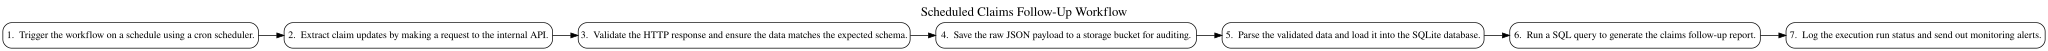

True

In [257]:
# ✍️ SQL DEVELOPER WORKSPACE — AUTO-FLOW
# TODO: Enter exactly seven ordered process steps. Keep this TODO guidance visible.
automation_steps = [
    " Trigger the workflow on a schedule using a cron scheduler.",
    " Extract claim updates by making a request to the internal API.",
    " Validate the HTTP response and ensure the data matches the expected schema.",
    " Save the raw JSON payload to a storage bucket for auditing.",
    " Parse the validated data and load it into the SQLite database.",
    " Run a SQL query to generate the claims follow-up report.",
    " Log the execution run status and send out monitoring alerts."
]
auto_keywords=[['scheduler'],['api'],['http','schema'],['json'],['sqlite'],['sql','report'],['log']]
validate_sequence('AUTO-FLOW',automation_steps,auto_keywords,'Scheduled Claims Follow-Up Workflow')

### Expected Output — AUTO-FLOW

Exactly seven ordered steps and a visible left-to-right diagram. The validator checks the presence and order of scheduler, API call, HTTP/schema validation, raw JSON, SQLite load, SQL report, and logging/monitoring.

## AUTO-REPORT — Write the Scheduled Claims Follow-Up Report

**Business requirement:** At each scheduled run, Claims Operations needs open claim-related exceptions grouped by insurer and severity, with counts, total exception value, and the oldest claim age.

**Tables to use:** `billing_claim_exceptions`, `insurers`, `claims`.

In [258]:
# ✍️ SQL DEVELOPER WORKSPACE — AUTO-REPORT
# TODO: Write the scheduled operational SQL report. Keep this TODO guidance visible.
auto_report_query = """
SELECT
    i.insurer_name,
    e.severity,
    COUNT(e.exception_id) AS open_exception_count,
    SUM(e.exception_amount) AS total_exception_value,
    MAX(CAST(julianday('2026-07-05') - julianday(c.submitted_date) AS INTEGER)) AS oldest_claim_age_days
FROM billing_claim_exceptions AS e
LEFT JOIN claims AS c ON e.claim_id = c.claim_id
LEFT JOIN insurers AS i ON c.insurer_id = i.insurer_id
WHERE e.status = 'OPEN'
  AND e.claim_id IS NOT NULL
GROUP BY i.insurer_name, e.severity
ORDER BY
    CASE e.severity
        WHEN 'CRITICAL' THEN 1
        WHEN 'HIGH' THEN 2
        WHEN 'MEDIUM' THEN 3
        WHEN 'LOW' THEN 4
        ELSE 5
    END ASC,
    total_exception_value DESC;
"""
validate_sql('AUTO-REPORT', auto_report_query)

,insurer_name,severity,open_exception_count,total_exception_value,oldest_claim_age_days
0,EverSure Health,CRITICAL,3,47840.00,79
1,CareBridge TPA,CRITICAL,2,36180.00,52
2,Wellness Shield TPA,CRITICAL,1,35275.00,60
3,Aarogya Secure Insurance,CRITICAL,2,12102.50,36
4,Bharat Health Cover,CRITICAL,2,11205.00,80
5,Dhanvantari Assurance,CRITICAL,2,5640.00,56
6,Wellness Shield TPA,HIGH,15,197040.00,89
7,Bharat Health Cover,HIGH,11,149450.00,71
8,CareBridge TPA,HIGH,12,131415.00,90
9,PrimeCare Insurance,HIGH,9,78065.00,91


,Check,Passed
0,Columns,True
1,Row count,True
2,Stable first row / key result,True


AUTO-REPORT: Passed


,insurer_name,severity,open_exception_count,total_exception_value,oldest_claim_age_days
0,EverSure Health,CRITICAL,3,47840.00,79
1,CareBridge TPA,CRITICAL,2,36180.00,52
2,Wellness Shield TPA,CRITICAL,1,35275.00,60
3,Aarogya Secure Insurance,CRITICAL,2,12102.50,36
4,Bharat Health Cover,CRITICAL,2,11205.00,80
5,Dhanvantari Assurance,CRITICAL,2,5640.00,56
6,Wellness Shield TPA,HIGH,15,197040.00,89
7,Bharat Health Cover,HIGH,11,149450.00,71
8,CareBridge TPA,HIGH,12,131415.00,90
9,PrimeCare Insurance,HIGH,9,78065.00,91


#### Expected Output — AUTO-REPORT

**Required columns:** `insurer_name` | `severity` | `open_exception_count` | `total_exception_value` | `oldest_claim_age_days`  
**Expected row count:** **22**

**Stable first row / key result**

| Column | Stable first-row value |
|---|---|
| `insurer_name` | `EverSure Health` |
| `severity` | `CRITICAL` |
| `open_exception_count` | `3` |
| `total_exception_value` | `47840.0` |
| `oldest_claim_age_days` | `79` |

**Hint:** Use grouped aggregation, LEFT JOINs, a severity-aware ORDER BY, and a date-age calculation.

## AUTO-CRON — Write Cron Expressions

Enter the four five-field cron expressions. These expressions are cron-ready, but a Google Colab runtime cannot remain active as a permanent scheduler after the runtime stops.

In [259]:
# ✍️ SQL DEVELOPER WORKSPACE — AUTO-CRON
# TODO: Fill all four cron expressions. Keep this TODO guidance visible.
cron_expressions = {
    'Three times per day': '0 8,12,16 * * *',
    'Weekday 5 PM': '0 17 * * 1-5',
    'Daily midnight': '0 0 * * *',
    'Sunday 2 AM': '0 2 * * 0'
}
validate_cron(cron_expressions)

,Scenario,Expression,Expected,Passed
0,Three times per day,"0 8,12,16 * * *","0 8,12,16 * * *",True
1,Weekday 5 PM,0 17 * * 1-5,0 17 * * 1-5,True
2,Daily midnight,0 0 * * *,0 0 * * *,True
3,Sunday 2 AM,0 2 * * 0,0 2 * * 0,True


AUTO-CRON: Passed


### Expected Output — AUTO-CRON

| Scenario | Expected expression |
|---|---|
| Daily at 8 AM, 12 PM, and 4 PM | `0 8,12,16 * * *` |
| Every weekday at 5 PM | `0 17 * * 1-5` |
| Every day at midnight | `0 0 * * *` |
| Every Sunday at 2 AM | `0 2 * * 0` |

# 7. Engineering Practices

## ENG-GIT — Git Collaboration Workflow

Represent the professional collaboration sequence as exactly eight ordered descriptions. No Git command execution is required.

,Step,Developer workflow
0,1,1. Read the ticket and understand the business...
1,2,2. Create a new feature branch to isolate the ...
2,3,3. Write the necessary SQL changes in the deve...
3,4,4. Test and validate the SQL queries against e...
4,5,5. Commit the changes to the local branch with...
5,6,6. Push the committed branch to the remote rep...
6,7,7. Open a pull request and request a code revi...
7,8,8. Merge the branch into the main codebase aft...


ENG-GIT: Passed | Exact count and ordered concepts checked.


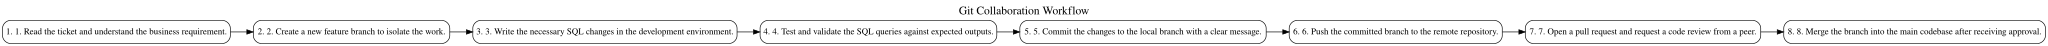

True

In [260]:
# ✍️ SQL DEVELOPER WORKSPACE — ENG-GIT
# TODO: Enter exactly eight ordered Git collaboration steps. Keep this TODO guidance visible.
# ✍️ SQL DEVELOPER WORKSPACE — ENG-GIT
# TODO: Enter exactly eight ordered Git collaboration steps. Keep this TODO guidance visible.
git_steps = [
    "1. Read the ticket and understand the business requirement.",
    "2. Create a new feature branch to isolate the work.",
    "3. Write the necessary SQL changes in the development environment.",
    "4. Test and validate the SQL queries against expected outputs.",
    "5. Commit the changes to the local branch with a clear message.",
    "6. Push the committed branch to the remote repository.",
    "7. Open a pull request and request a code review from a peer.",
    "8. Merge the branch into the main codebase after receiving approval."
]

git_keywords=[['requirement'],['branch'],['sql'],['test','valid'],['commit'],['push'],['pull request','review'],['merge','approval']]
validate_sequence('ENG-GIT',git_steps,git_keywords,'Git Collaboration Workflow')

### Expected Output — ENG-GIT

Eight ordered steps: read requirement/ticket → create feature branch → write SQL change → test/validate → commit → push → pull request/review → merge after approval. A visible diagram appears after validation.

## ENG-CHANGE — Safe Database Change Workflow

Represent a safe database-change sequence as exactly eight ordered descriptions, including backup/rollback planning and post-deployment monitoring.

,Step,Developer workflow
0,1,1. Read and understand the business requiremen...
1,2,2. Formulate a secure backup and rollback plan...
2,3,3. Write the necessary sql change script to ap...
3,4,4. Thoroughly test the script in a safe develo...
4,5,5. Submit the proposed script for a thorough p...
5,6,6. Proceed to deploy the approved change to th...
6,7,7. Closely monitor the system logs and perform...
7,8,8. Immediately roll back the changes if any cr...


ENG-CHANGE: Passed | Exact count and ordered concepts checked.


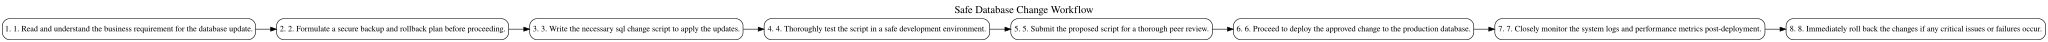

True

In [261]:
# ✍️ SQL DEVELOPER WORKSPACE — ENG-CHANGE
# TODO: Enter exactly eight ordered safe database-change steps. Keep this TODO guidance visible.
change_steps = [
    "1. Read and understand the business requirement for the database update.",
    "2. Formulate a secure backup and rollback plan before proceeding.",
    "3. Write the necessary sql change script to apply the updates.",
    "4. Thoroughly test the script in a safe development environment.",
    "5. Submit the proposed script for a thorough peer review.",
    "6. Proceed to deploy the approved change to the production database.",
    "7. Closely monitor the system logs and performance metrics post-deployment.",
    "8. Immediately roll back the changes if any critical issues or failures occur."
]

change_keywords=[['requirement'],['backup','rollback'],['sql','change'],['test','development'],['peer','review'],['deploy','approved'],['monitor'],['roll back']]
validate_sequence('ENG-CHANGE',change_steps,change_keywords,'Safe Database Change Workflow')

### Expected Output — ENG-CHANGE

Eight ordered steps: understand requirement → backup and rollback plan → write migration/SQL change → test in development → peer review → deploy approved change → monitor logs/results → roll back if deployment fails. A visible diagram appears after validation.

# 8. Progress Check

In [262]:
completion_dashboard_df, completion_status_counts = completion_dashboard()
display(completion_dashboard_df); display(completion_status_counts)
print(f"Passed activities: {(completion_dashboard_df['Status']=='Passed').sum()} / {len(completion_dashboard_df)}")

,Activity ID,Status
0,ER-1,Passed
1,API-Q1,Passed
2,API-Q2,Passed
3,API-Q3,Passed
4,API-Q4,Passed
5,API-Q5,Passed
6,Q1,Passed
7,Q2,Passed
8,Q3,Passed
9,Q4,Passed


,Status,Count
0,Passed,26


Passed activities: 26 / 26
